In [3]:
!pip install yfinance pyts tensorflow scikit-learn statsmodels matplotlib seaborn pandas numpy scipy -q

print("=" * 60)
print("PACKAGE INSTALLATION COMPLETE")
print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 45.2 MB/s eta 0:00:00
PACKAGE INSTALLATION COMPLETE


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

import random
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

from scipy import stats
from scipy.stats import gaussian_kde
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Conv2D, MaxPooling2D,
                                     Flatten, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from pyts.image import GramianAngularField

print("=" * 60)
print("ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"TensorFlow : {tf.__version__}")

ALL LIBRARIES IMPORTED SUCCESSFULLY
NumPy      : 2.0.2
Pandas     : 2.2.2
TensorFlow : 2.19.0


In [26]:
# ── GLOBAL PLOT STYLE ─────────────────────────────────────────────────────────

FIG_SIZE  = (14, 5)
FIG_SQ    = (8, 6)
FIG_3COL  = (14, 5)
DPI       = 150

C = dict(
    indigo  = '#6366F1',
    rose    = '#F43F5E',
    emerald = '#10B981',
    amber   = '#F59E0B',
    sky     = '#38BDF8',
    violet  = '#8B5CF6',
    slate   = '#64748B',
    dark    = '#0F172A',
    success = '#22C55E',
    danger  = '#EF4444',
)

plt.rcParams.update({
    'figure.dpi'          : DPI,
    'figure.facecolor'    : 'white',
    'axes.facecolor'      : '#F8FAFC',
    'axes.edgecolor'      : '#CBD5E1',
    'axes.linewidth'      : 0.8,
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.titlesize'      : 14,
    'axes.titleweight'    : 'bold',
    'axes.titlepad'       : 12,
    'axes.labelsize'      : 11,
    'axes.labelcolor'     : '#1E293B',
    'axes.grid'           : True,
    'grid.color'          : '#E2E8F0',
    'grid.linewidth'      : 0.6,
    'grid.alpha'          : 1.0,
    'xtick.labelsize'     : 10,
    'ytick.labelsize'     : 10,
    'xtick.color'         : '#475569',
    'ytick.color'         : '#475569',
    'legend.fontsize'     : 10,
    'legend.framealpha'   : 0.9,
    'legend.edgecolor'    : '#CBD5E1',
    'legend.fancybox'     : False,
    'lines.linewidth'     : 1.8,
    'font.family'         : 'sans-serif',
})

print("Plot style configured - all figures will use FIG_SIZE =", FIG_SIZE, "| DPI =", DPI)

Plot style configured - all figures will use FIG_SIZE = (14, 5) | DPI = 150


In [6]:
# ── GLOBAL CONFIG — all hyperparameters in one place ────────────────────────

TICKER      = "BTC-USD"
START_DATE  = "2018-01-01"
END_DATE    = "2023-06-01"
MAX_ROWS    = 2000

MLP_WINDOW  = 10
GAF_WINDOW  = 24
TRAIN_RATIO = 0.8
VAL_SPLIT   = 0.1

MLP_EPOCHS  = 100
CNN_EPOCHS  = 50
BATCH_SIZE  = 32
MLP_PATIENCE = 15
CNN_PATIENCE = 10
LR          = 1e-3
FRAC_THRESHOLD = 1e-5

print("Config loaded:")
for k, v in [("Ticker", TICKER), ("MLP window", MLP_WINDOW), ("GAF window", GAF_WINDOW),
             ("Train/test split", TRAIN_RATIO), ("Batch size", BATCH_SIZE)]:
    print(f"  {k}: {v}")

Config loaded:
  Ticker: BTC-USD
  MLP window: 10
  GAF window: 24
  Train/test split: 0.8
  Batch size: 32


In [27]:
print(f"Downloading {TICKER} data from Yahoo Finance...")
df = yf.download(TICKER, start=START_DATE, end=END_DATE,
                 auto_adjust=True, progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

close = df["Close"].dropna().iloc[:MAX_ROWS]

if len(close) < 500:
    raise ValueError(f"Only {len(close)} rows downloaded — check connection.")

print(f"Ticker   : {TICKER}")
print(f"Rows     : {len(close)}")
print(f"From     : {close.index[0].date()}  →  To: {close.index[-1].date()}")
print(f"Range    : {close.min():.2f} - {close.max():.2f}")
print(close.head())

Ticker   : BTC-USD
Rows     : 1977
From     : 2018-01-01  →  To: 2023-05-31
Range    : 3236.76 - 67566.83
Date
2018-01-01    13657.200195
2018-01-02    14982.099609
2018-01-03    15201.000000
2018-01-04    15599.200195
2018-01-05    17429.500000
Name: Close, dtype: float64


## Time Series Analysis

### Raw Price Series (Levels)

RAW PRICE SERIES (LEVELS) ANALYSIS


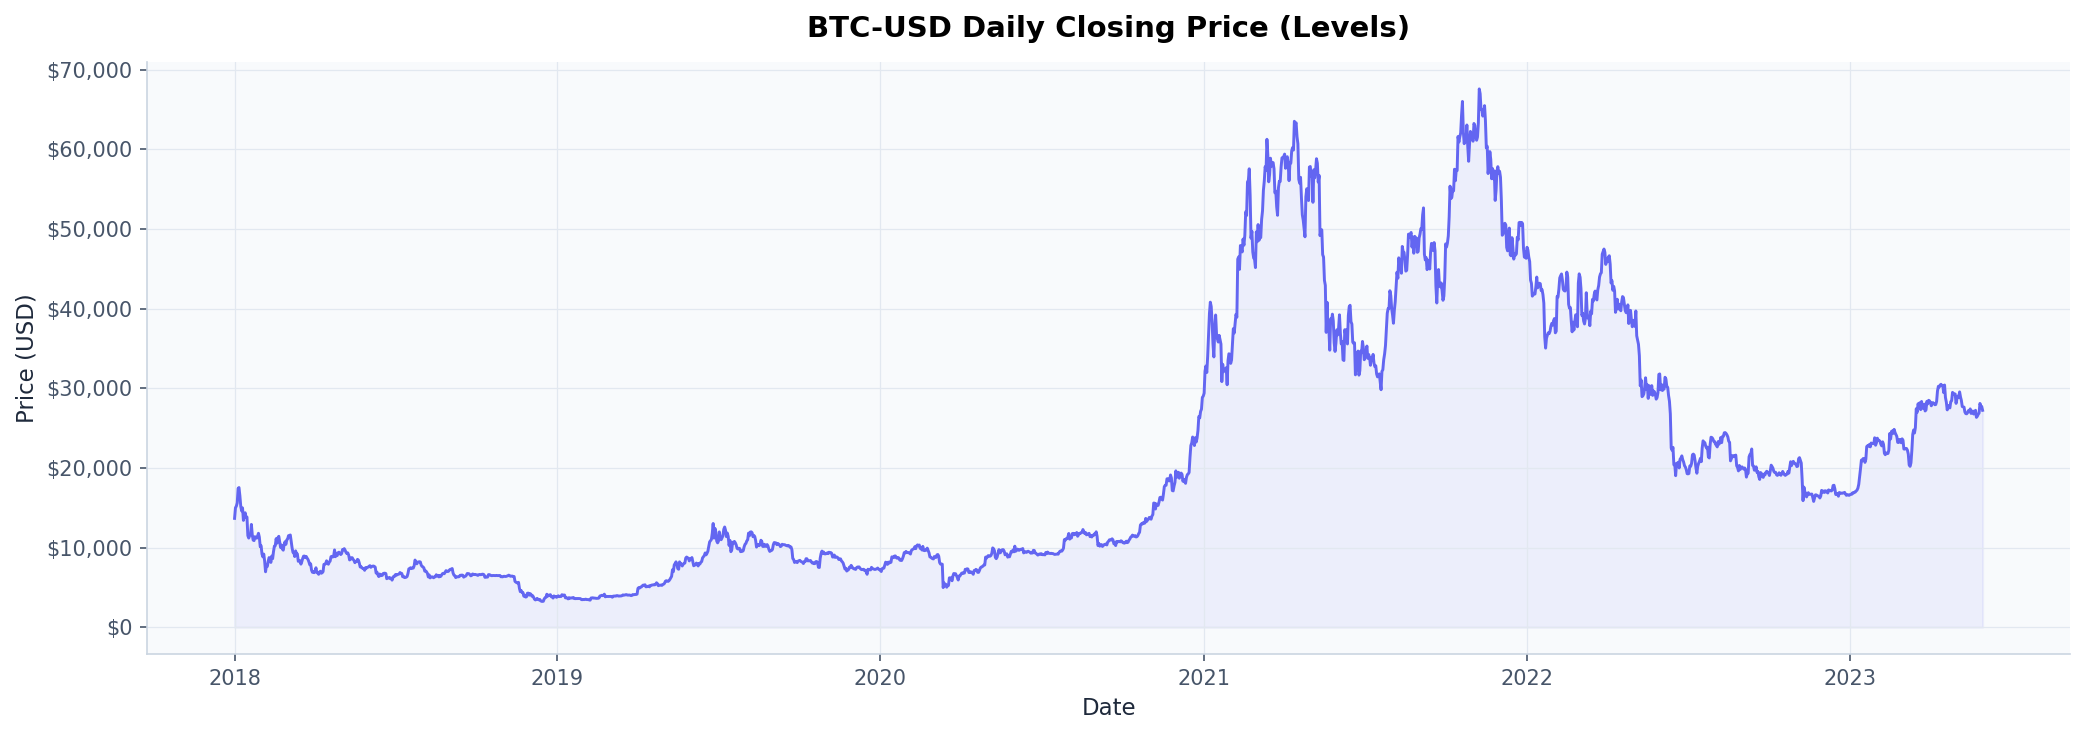


Summary Statistics - Price Levels:
               Value
Mean      20695.7703
Median    11805.6533
Std Dev   16401.3527
Skewness      0.9921
Kurtosis     -0.2058
Min        3236.7617
Max       67566.8281
25th Pct   8027.2681
75th Pct  30825.6992


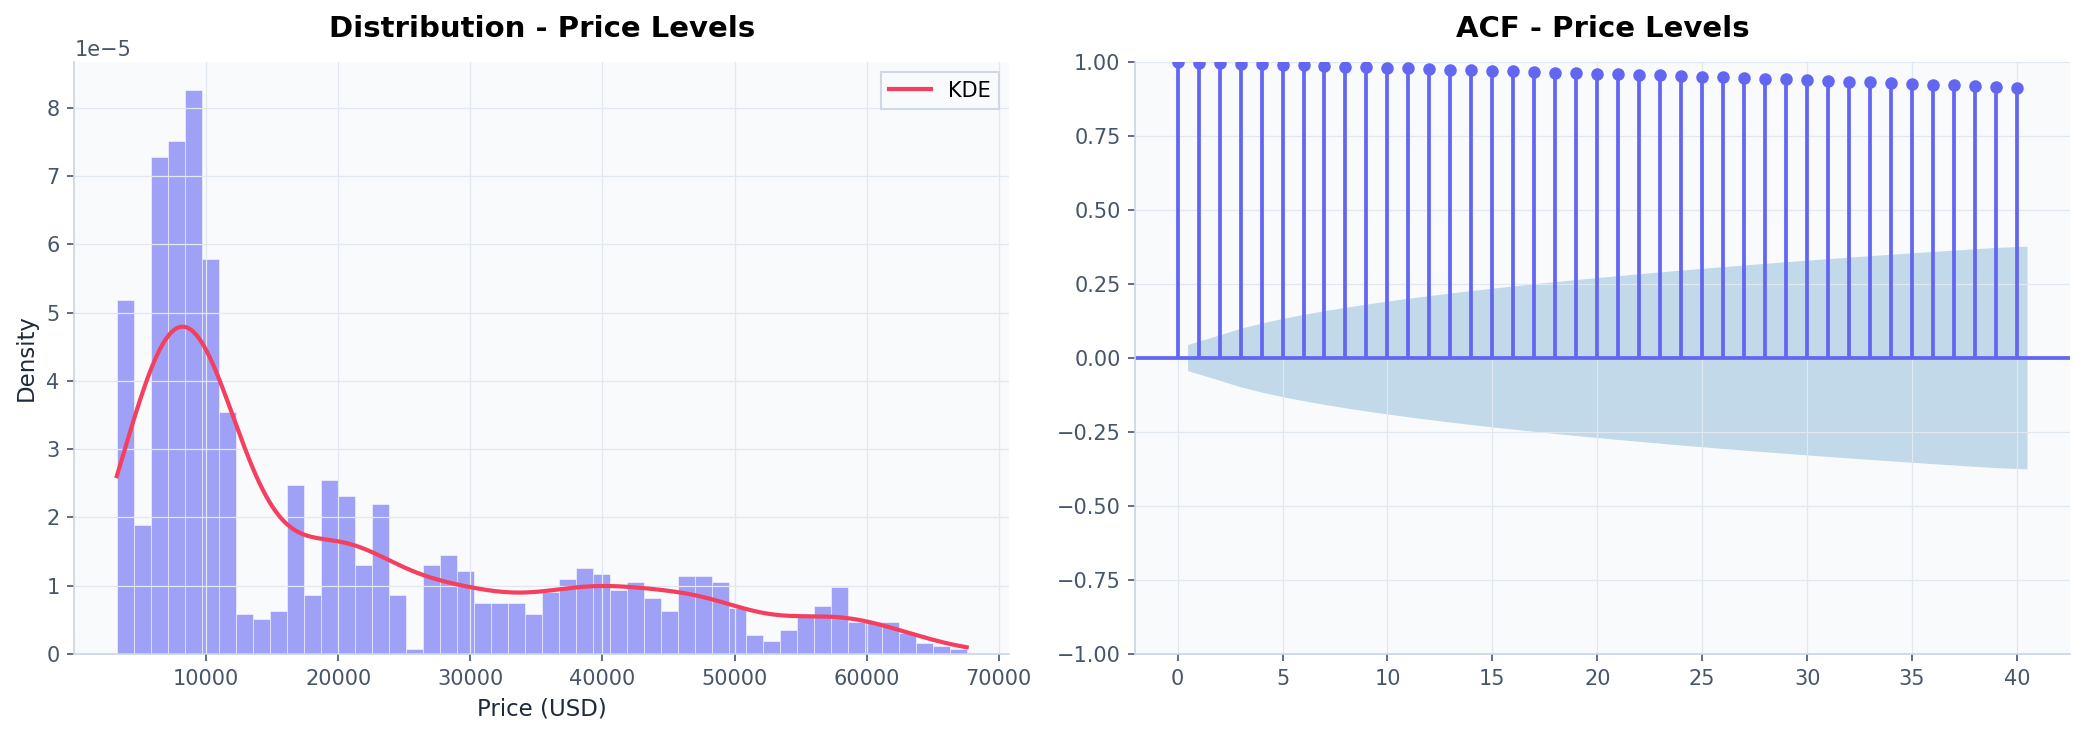

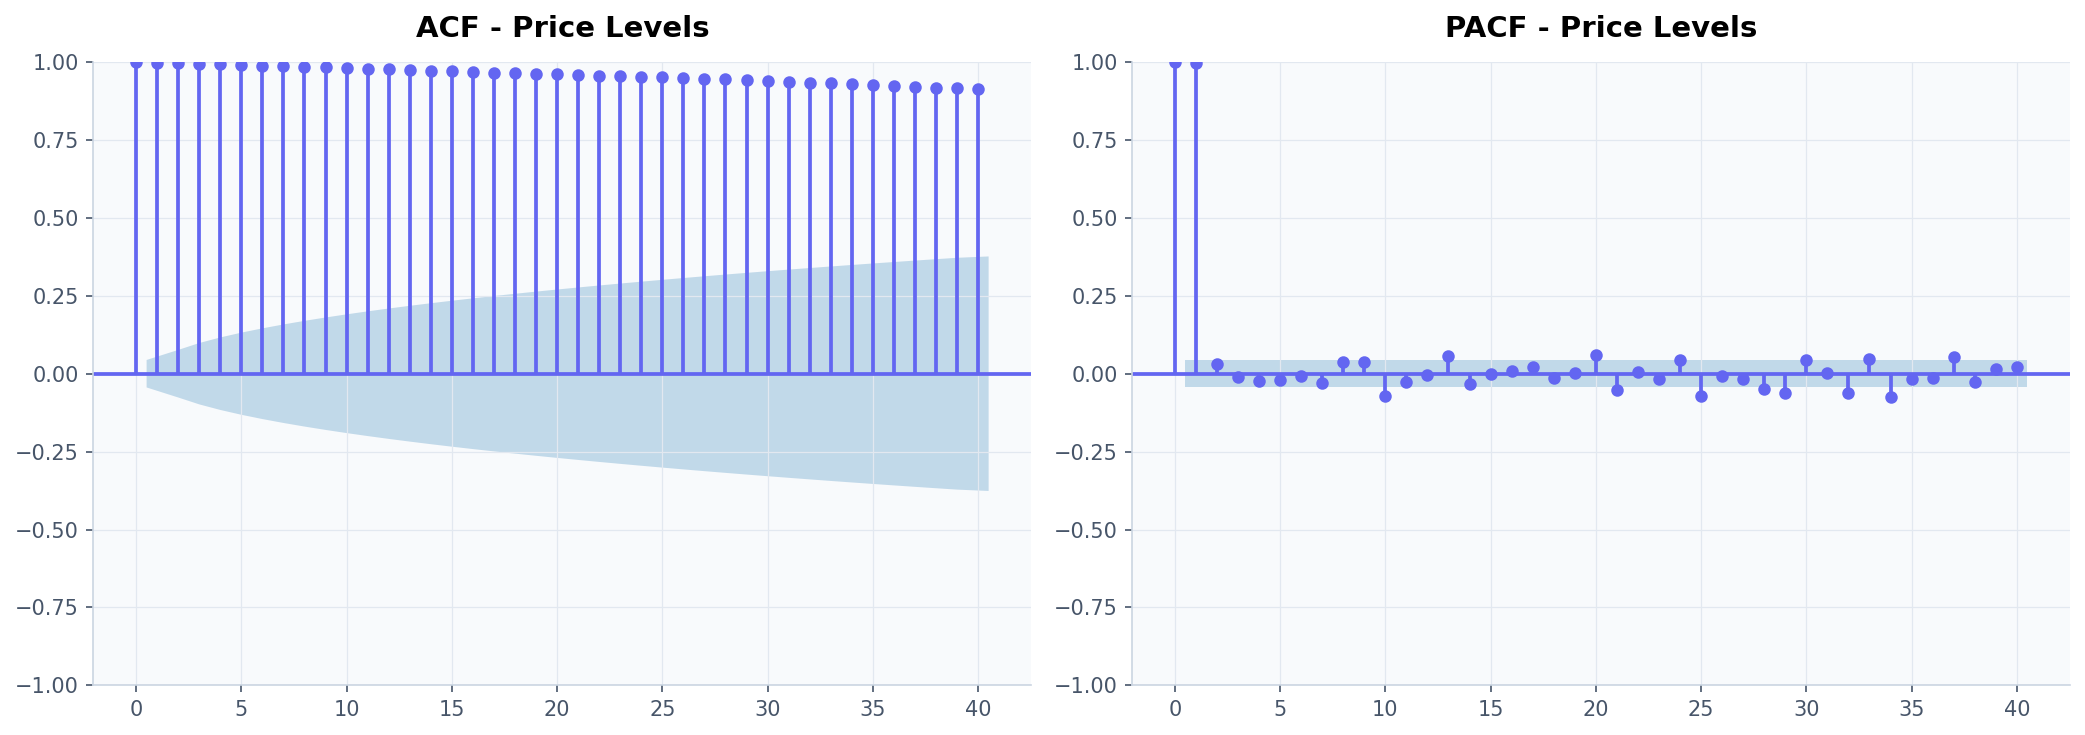


ADF Test - Price Levels
  Statistic : -1.423500  |  p-value : 0.570960
  Conclusion: NON-STATIONARY


In [8]:
print("=" * 60)
print("RAW PRICE SERIES (LEVELS) ANALYSIS")
print("=" * 60)

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.fill_between(close.index, close.values, alpha=0.08, color=C['indigo'])
ax.plot(close.index, close.values, color=C['indigo'], lw=1.4)
ax.set_title('BTC-USD Daily Closing Price (Levels)')
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout(); plt.show()

summary_levels = {
    'Mean': close.mean(), 'Median': close.median(), 'Std Dev': close.std(),
    'Skewness': stats.skew(close), 'Kurtosis': stats.kurtosis(close),
    'Min': close.min(), 'Max': close.max(),
    '25th Pct': close.quantile(0.25), '75th Pct': close.quantile(0.75)
}
print("\nSummary Statistics - Price Levels:")
print(pd.DataFrame([summary_levels]).T.rename(columns={0:'Value'}).round(4))

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
axes[0].hist(close.values, bins=50, density=True, color=C['indigo'],
             alpha=0.6, edgecolor='white', linewidth=0.4)
x_r = np.linspace(close.min(), close.max(), 300)
axes[0].plot(x_r, gaussian_kde(close.values)(x_r), color=C['rose'], lw=2, label='KDE')
axes[0].set_title('Distribution - Price Levels')
axes[0].set_xlabel('Price (USD)'); axes[0].set_ylabel('Density'); axes[0].legend()
plot_acf(close.values, lags=40, ax=axes[1], title='ACF - Price Levels',
         color=C['indigo'], vlines_kwargs={'colors': C['indigo']})
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
plot_acf(close.values,  lags=40, ax=axes[0], title='ACF - Price Levels',
         color=C['indigo'], vlines_kwargs={'colors': C['indigo']})
plot_pacf(close.values, lags=40, ax=axes[1], title='PACF - Price Levels',
          method='ywm', color=C['indigo'], vlines_kwargs={'colors': C['indigo']})
plt.tight_layout(); plt.show()

adf_levels = adfuller(close.values)
print("\nADF Test - Price Levels")
print(f"  Statistic : {adf_levels[0]:.6f}  |  p-value : {adf_levels[1]:.6f}")
print(f"  Conclusion: {'STATIONARY' if adf_levels[1] < 0.05 else 'NON-STATIONARY'}")

### Stationary Transformation (Log-Returns)

LOG-RETURNS ANALYSIS
Log-returns: 1976 observations


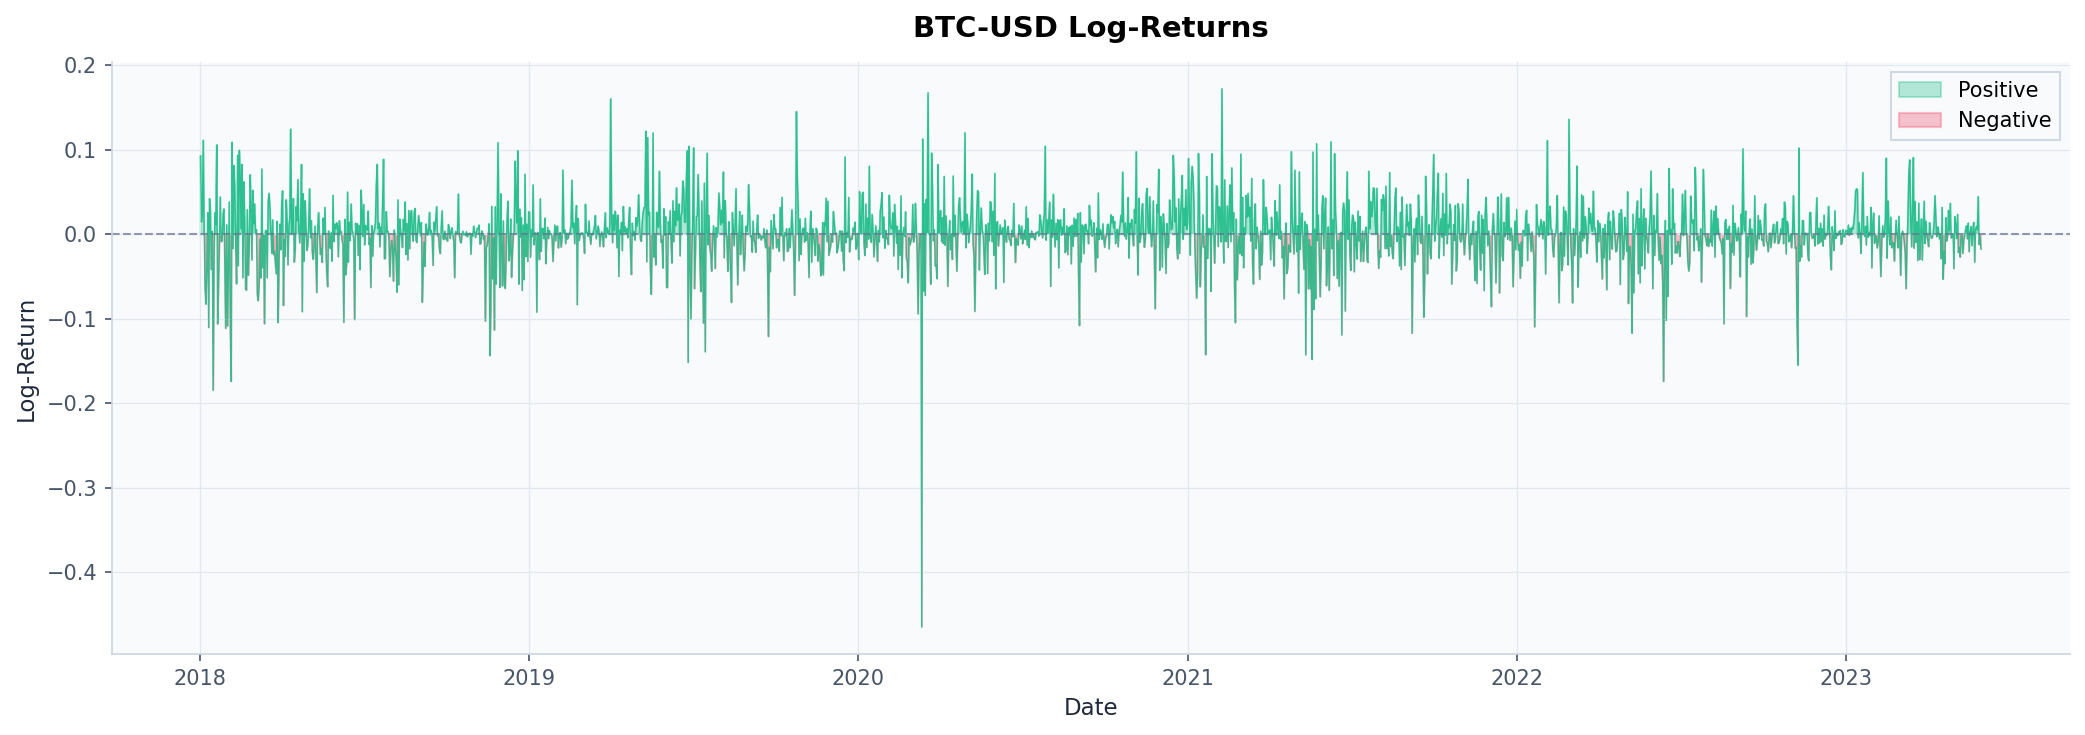


Summary Statistics - Log-Returns:
              Value
Mean       0.000349
Median     0.000870
Std Dev    0.038164
Skewness  -1.049240
Kurtosis  13.478607
Min       -0.464730
Max        0.171821
25th Pct  -0.015217
75th Pct   0.017054


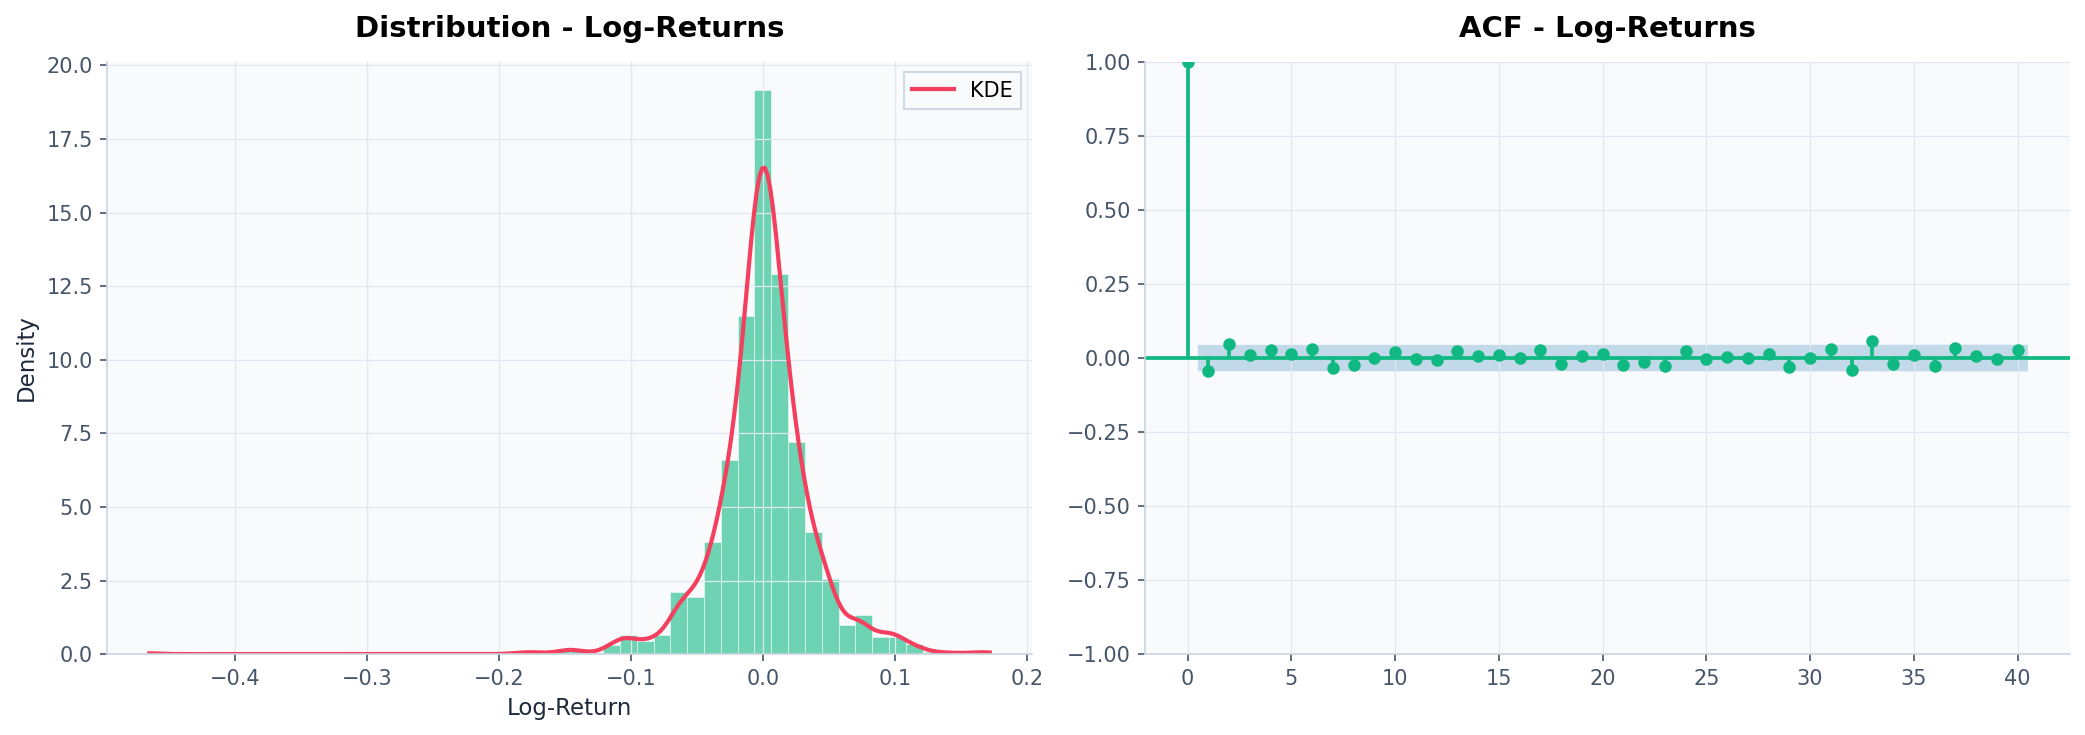

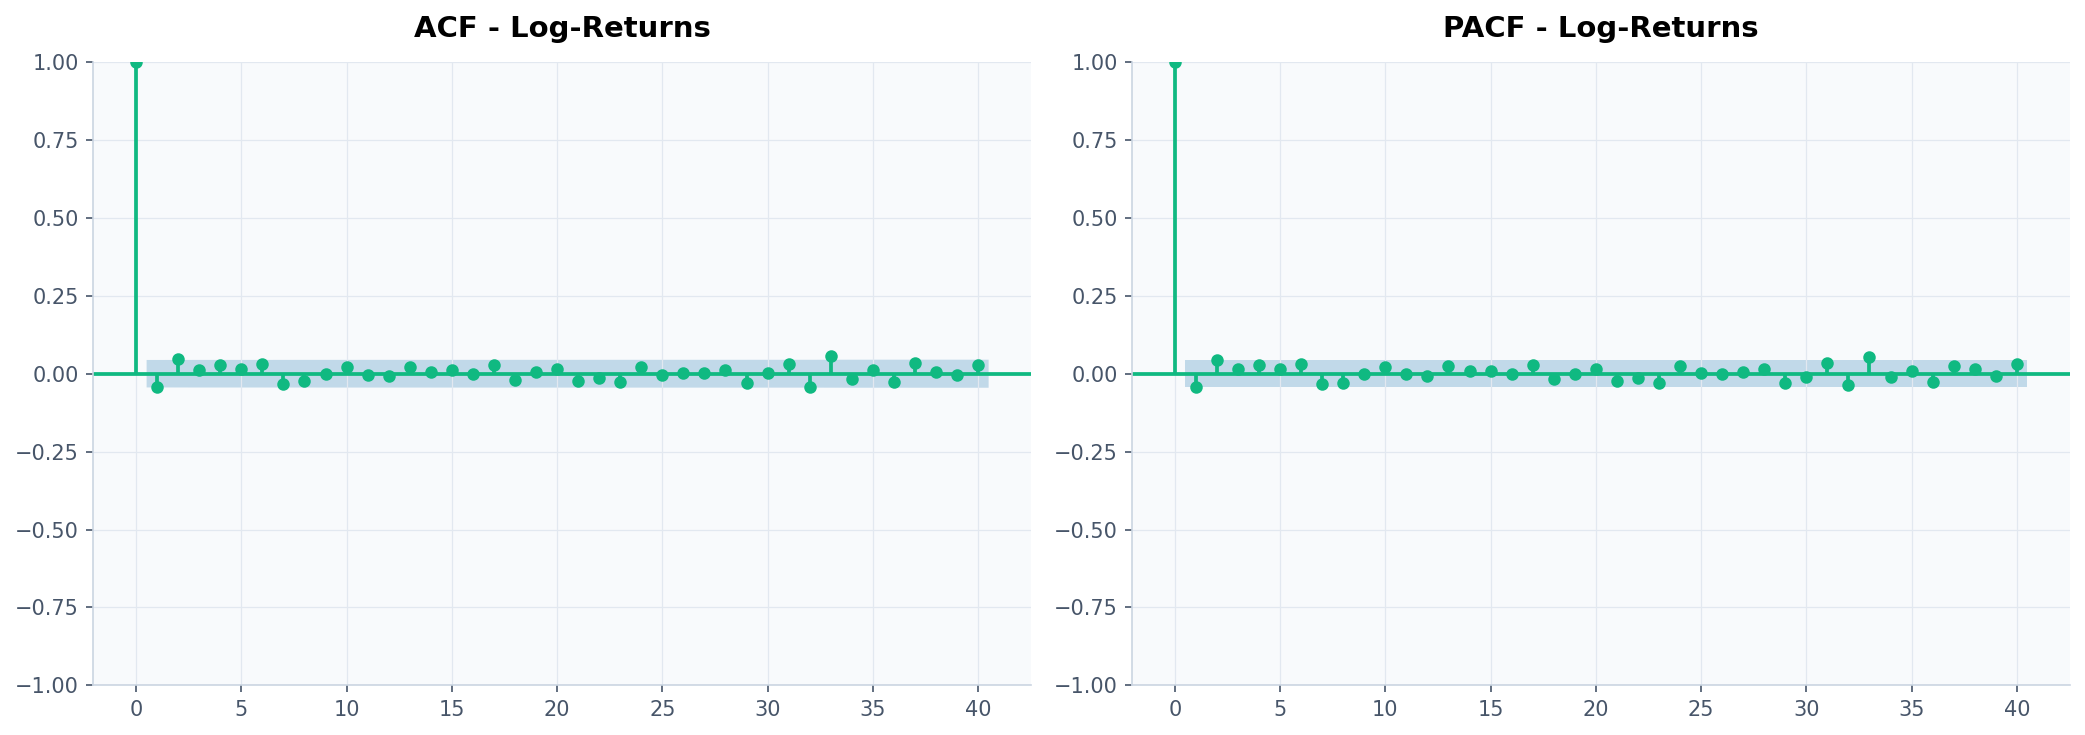


ADF Test - Log-Returns
  Statistic : -30.714218  |  p-value : 0.000000
  Conclusion: STATIONARY


In [9]:
print("=" * 60)
print("LOG-RETURNS ANALYSIS")
print("=" * 60)

log_returns = np.log(close / close.shift(1)).dropna()
print(f"Log-returns: {len(log_returns)} observations")

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.fill_between(log_returns.index, log_returns.values, 0,
                where=(log_returns.values >= 0), alpha=0.3, color=C['emerald'], label='Positive')
ax.fill_between(log_returns.index, log_returns.values, 0,
                where=(log_returns.values < 0),  alpha=0.3, color=C['rose'],    label='Negative')
ax.plot(log_returns.index, log_returns.values, color=C['emerald'], lw=0.7, alpha=0.8)
ax.axhline(0, color=C['slate'], ls='--', lw=1, alpha=0.7)
ax.set_title('BTC-USD Log-Returns')
ax.set_xlabel('Date'); ax.set_ylabel('Log-Return'); ax.legend()
plt.tight_layout(); plt.show()

summary_lr = {
    'Mean': log_returns.mean(), 'Median': log_returns.median(), 'Std Dev': log_returns.std(),
    'Skewness': stats.skew(log_returns), 'Kurtosis': stats.kurtosis(log_returns),
    'Min': log_returns.min(), 'Max': log_returns.max(),
    '25th Pct': log_returns.quantile(0.25), '75th Pct': log_returns.quantile(0.75)
}
print("\nSummary Statistics - Log-Returns:")
print(pd.DataFrame([summary_lr]).T.rename(columns={0:'Value'}).round(6))

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
axes[0].hist(log_returns.values, bins=50, density=True, color=C['emerald'],
             alpha=0.6, edgecolor='white', linewidth=0.4)
x_lr = np.linspace(log_returns.min(), log_returns.max(), 300)
axes[0].plot(x_lr, gaussian_kde(log_returns.values)(x_lr), color=C['rose'], lw=2, label='KDE')
axes[0].set_title('Distribution - Log-Returns')
axes[0].set_xlabel('Log-Return'); axes[0].set_ylabel('Density'); axes[0].legend()
plot_acf(log_returns.values, lags=40, ax=axes[1], title='ACF - Log-Returns',
         color=C['emerald'], vlines_kwargs={'colors': C['emerald']})
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
plot_acf(log_returns.values,  lags=40, ax=axes[0], title='ACF - Log-Returns',
         color=C['emerald'], vlines_kwargs={'colors': C['emerald']})
plot_pacf(log_returns.values, lags=40, ax=axes[1], title='PACF - Log-Returns',
          method='ywm', color=C['emerald'], vlines_kwargs={'colors': C['emerald']})
plt.tight_layout(); plt.show()

adf_logret = adfuller(log_returns.values)
print("\nADF Test - Log-Returns")
print(f"  Statistic : {adf_logret[0]:.6f}  |  p-value : {adf_logret[1]:.6f}")
print(f"  Conclusion: {'STATIONARY' if adf_logret[1] < 0.05 else 'NON-STATIONARY'}")

### Fractional Differencing

FRACTIONAL DIFFERENCING
Searching for optimal d* ...


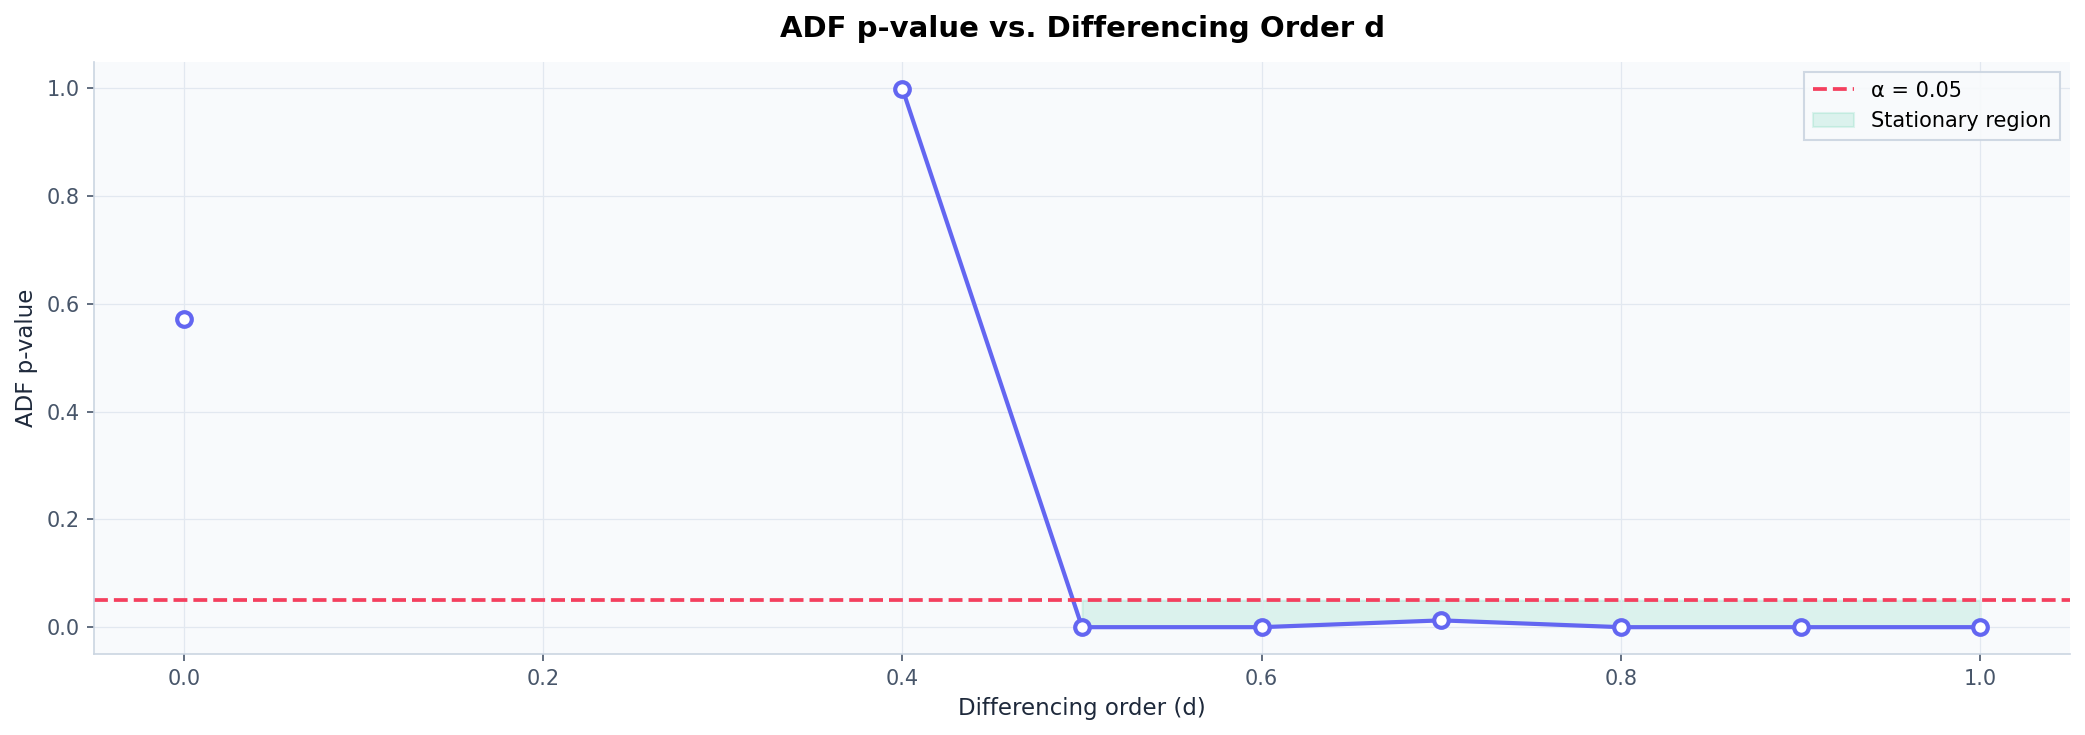

Optimal d* = 0.5
ADF p-value at d* = 0.000001
Fractionally differenced series: 1051 observations


In [10]:
print("=" * 60)
print("FRACTIONAL DIFFERENCING")
print("=" * 60)

def get_weights(d, size):
    w = [1.0]
    for k in range(1, size):
        w.append(-w[-1] * (d - k + 1) / k)
    return np.array(w)

def frac_diff_fixed_window(series, d, threshold=FRAC_THRESHOLD):
    n = len(series)
    weights = get_weights(d, n)
    weights = weights[np.abs(weights) > threshold]
    width   = len(weights)
    if width > n:
        return np.full(n, np.nan)
    conv   = np.convolve(series, weights[::-1], mode='full')
    result = np.full(n, np.nan)
    result[width - 1:] = conv[:n - width + 1]
    return result

d_values = np.arange(0.0, 1.1, 0.1)
adf_pvalues, adf_stats_list = [], []

print("Searching for optimal d* ...")
for d in d_values:
    fs = frac_diff_fixed_window(close.values, d)
    fs_clean = fs[~np.isnan(fs)]
    if len(fs_clean) > 100:
        r = adfuller(fs_clean)
        adf_pvalues.append(r[1]); adf_stats_list.append(r[0])
    else:
        adf_pvalues.append(np.nan); adf_stats_list.append(np.nan)

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(d_values, adf_pvalues, color=C['indigo'], lw=2, marker='o',
        ms=7, markerfacecolor='white', markeredgewidth=2, markeredgecolor=C['indigo'])
ax.axhline(0.05, color=C['rose'], ls='--', lw=1.8, label='α = 0.05')
ax.fill_between(d_values, adf_pvalues, 0.05,
                where=[p < 0.05 if p == p else False for p in adf_pvalues],
                alpha=0.12, color=C['emerald'], label='Stationary region')
ax.set_xlabel('Differencing order (d)'); ax.set_ylabel('ADF p-value')
ax.set_title('ADF p-value vs. Differencing Order d')
ax.legend()
plt.tight_layout(); plt.show()

optimal_d = next((d for d, p in zip(d_values, adf_pvalues)
                  if p is not None and not np.isnan(p) and p < 0.05), 1.0)
print(f"Optimal d* = {optimal_d:.1f}")
idx_d = int(round(optimal_d * 10))
if not np.isnan(adf_pvalues[idx_d]):
    print(f"ADF p-value at d* = {adf_pvalues[idx_d]:.6f}")

frac_raw   = frac_diff_fixed_window(close.values, optimal_d)
frac_clean = frac_raw[~np.isnan(frac_raw)]
frac_idx   = close.index[-len(frac_clean):]
frac_diff_series = pd.Series(frac_clean, index=frac_idx)
print(f"Fractionally differenced series: {len(frac_diff_series)} observations")

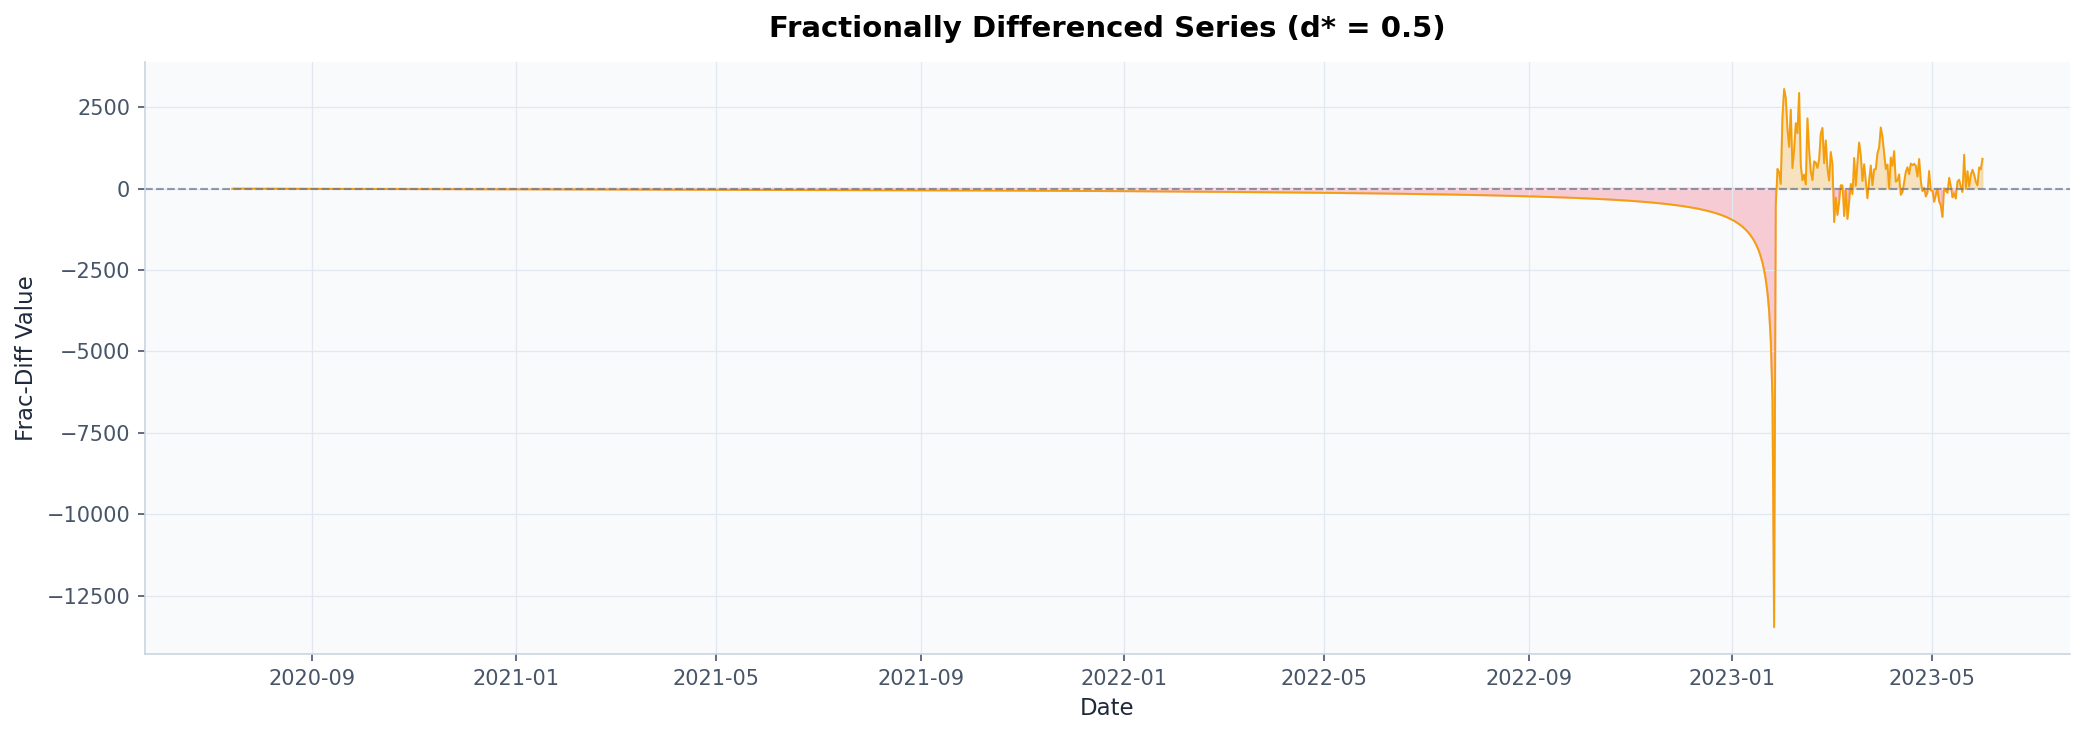

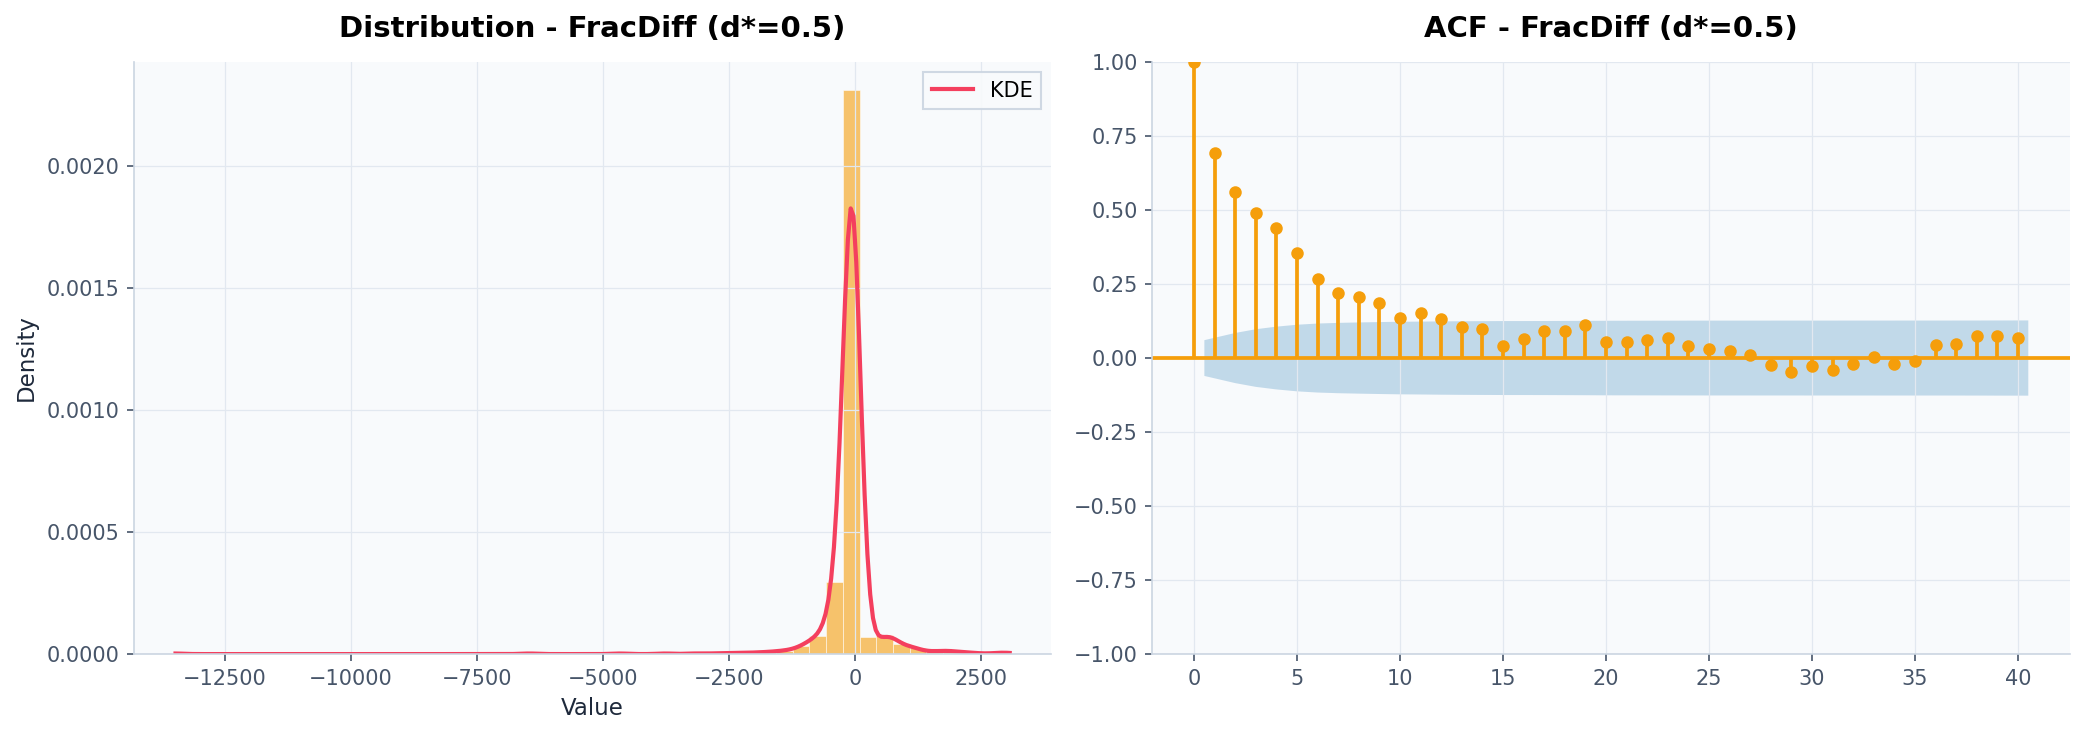

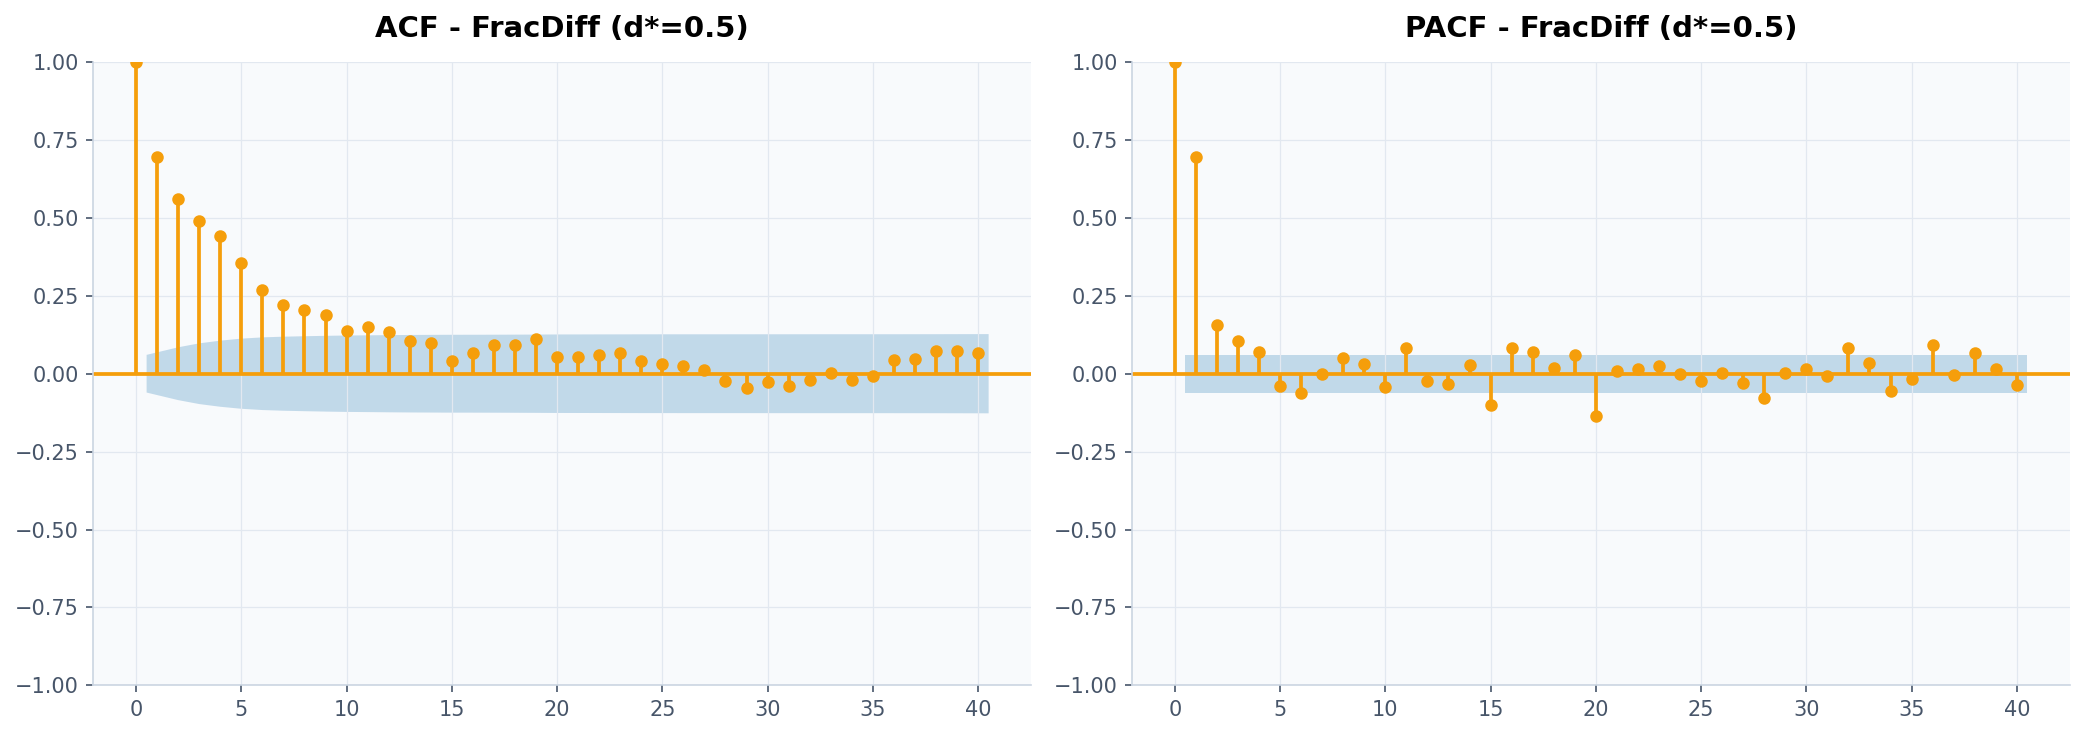

ADF - FracDiff  |  Statistic: -5.635446  |  p-value: 0.000001
Conclusion: STATIONARY
Correlation with original price levels: 0.080423


In [11]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.fill_between(frac_diff_series.index, frac_diff_series.values, 0,
                where=(frac_diff_series.values >= 0), alpha=0.25, color=C['amber'])
ax.fill_between(frac_diff_series.index, frac_diff_series.values, 0,
                where=(frac_diff_series.values < 0),  alpha=0.25, color=C['rose'])
ax.plot(frac_diff_series.index, frac_diff_series.values, color=C['amber'], lw=0.9)
ax.axhline(0, color=C['slate'], ls='--', lw=1, alpha=0.7)
ax.set_title(f'Fractionally Differenced Series (d* = {optimal_d})')
ax.set_xlabel('Date'); ax.set_ylabel('Frac-Diff Value')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
axes[0].hist(frac_diff_series.values, bins=50, density=True, color=C['amber'],
             alpha=0.6, edgecolor='white', linewidth=0.4)
x_f = np.linspace(frac_diff_series.min(), frac_diff_series.max(), 300)
axes[0].plot(x_f, gaussian_kde(frac_diff_series.values)(x_f), color=C['rose'], lw=2, label='KDE')
axes[0].set_title(f'Distribution - FracDiff (d*={optimal_d})')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Density'); axes[0].legend()
plot_acf(frac_diff_series.values, lags=40, ax=axes[1],
         title=f'ACF - FracDiff (d*={optimal_d})',
         color=C['amber'], vlines_kwargs={'colors': C['amber']})
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
plot_acf(frac_diff_series.values,  lags=40, ax=axes[0],
         title=f'ACF - FracDiff (d*={optimal_d})',
         color=C['amber'], vlines_kwargs={'colors': C['amber']})
plot_pacf(frac_diff_series.values, lags=40, ax=axes[1],
          title=f'PACF - FracDiff (d*={optimal_d})', method='ywm',
          color=C['amber'], vlines_kwargs={'colors': C['amber']})
plt.tight_layout(); plt.show()

adf_frac = adfuller(frac_diff_series.values)
print(f"ADF - FracDiff  |  Statistic: {adf_frac[0]:.6f}  |  p-value: {adf_frac[1]:.6f}")
print(f"Conclusion: {'STATIONARY' if adf_frac[1] < 0.05 else 'NON-STATIONARY'}")
print(f"Correlation with original price levels: {frac_diff_series.reindex(close.index).corr(close):.6f}")

## Multi-Layer Perceptron (MLP) Models

### MLP on Price Levels

In [12]:
def make_callbacks(patience, lr_patience=None):
    """Return fresh callback instances for each training run."""
    cbs = [EarlyStopping(monitor='val_loss', patience=patience,
                         restore_best_weights=True, verbose=0)]
    if lr_patience:
        cbs.append(ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                     patience=lr_patience, min_lr=1e-6, verbose=0))
    return cbs

mlp_metrics = {}

def create_mlp_data(series, window_size):
    """Sliding-window supervised dataset from a 1-D series."""
    X = np.lib.stride_tricks.sliding_window_view(series, window_size)
    y = series[window_size:]
    return X, y

# ── Price Levels ───────────────────────────────────────────────────────────────
print("=" * 60)
print("MLP - PRICE LEVELS")
print("=" * 60)

X_lev, y_lev       = create_mlp_data(close.values, MLP_WINDOW)
split               = int(TRAIN_RATIO * len(X_lev))
X_tr_lev, X_te_lev = X_lev[:split], X_lev[split:]
y_tr_lev, y_te_lev = y_lev[:split], y_lev[split:]

sc_lev_X = MinMaxScaler(); sc_lev_y = MinMaxScaler()
X_tr_lev_sc = sc_lev_X.fit_transform(X_tr_lev)
X_te_lev_sc = sc_lev_X.transform(X_te_lev)
y_tr_lev_sc = sc_lev_y.fit_transform(y_tr_lev.reshape(-1, 1)).ravel()
y_te_lev_sc = sc_lev_y.transform(y_te_lev.reshape(-1, 1)).ravel()

mlp_lev = Sequential([
    Dense(64, activation='relu', input_shape=(MLP_WINDOW,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
mlp_lev.compile(optimizer=tf.keras.optimizers.Adam(LR), loss='mse')
mlp_lev.summary()

hist_lev = mlp_lev.fit(X_tr_lev_sc, y_tr_lev_sc,
                        epochs=MLP_EPOCHS, batch_size=BATCH_SIZE,
                        validation_split=VAL_SPLIT,
                        callbacks=make_callbacks(MLP_PATIENCE, MLP_PATIENCE // 2),
                        verbose=0)
print(f"Best epoch: {np.argmin(hist_lev.history['val_loss']) + 1}")

MLP - PRICE LEVELS


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

Best epoch: 33


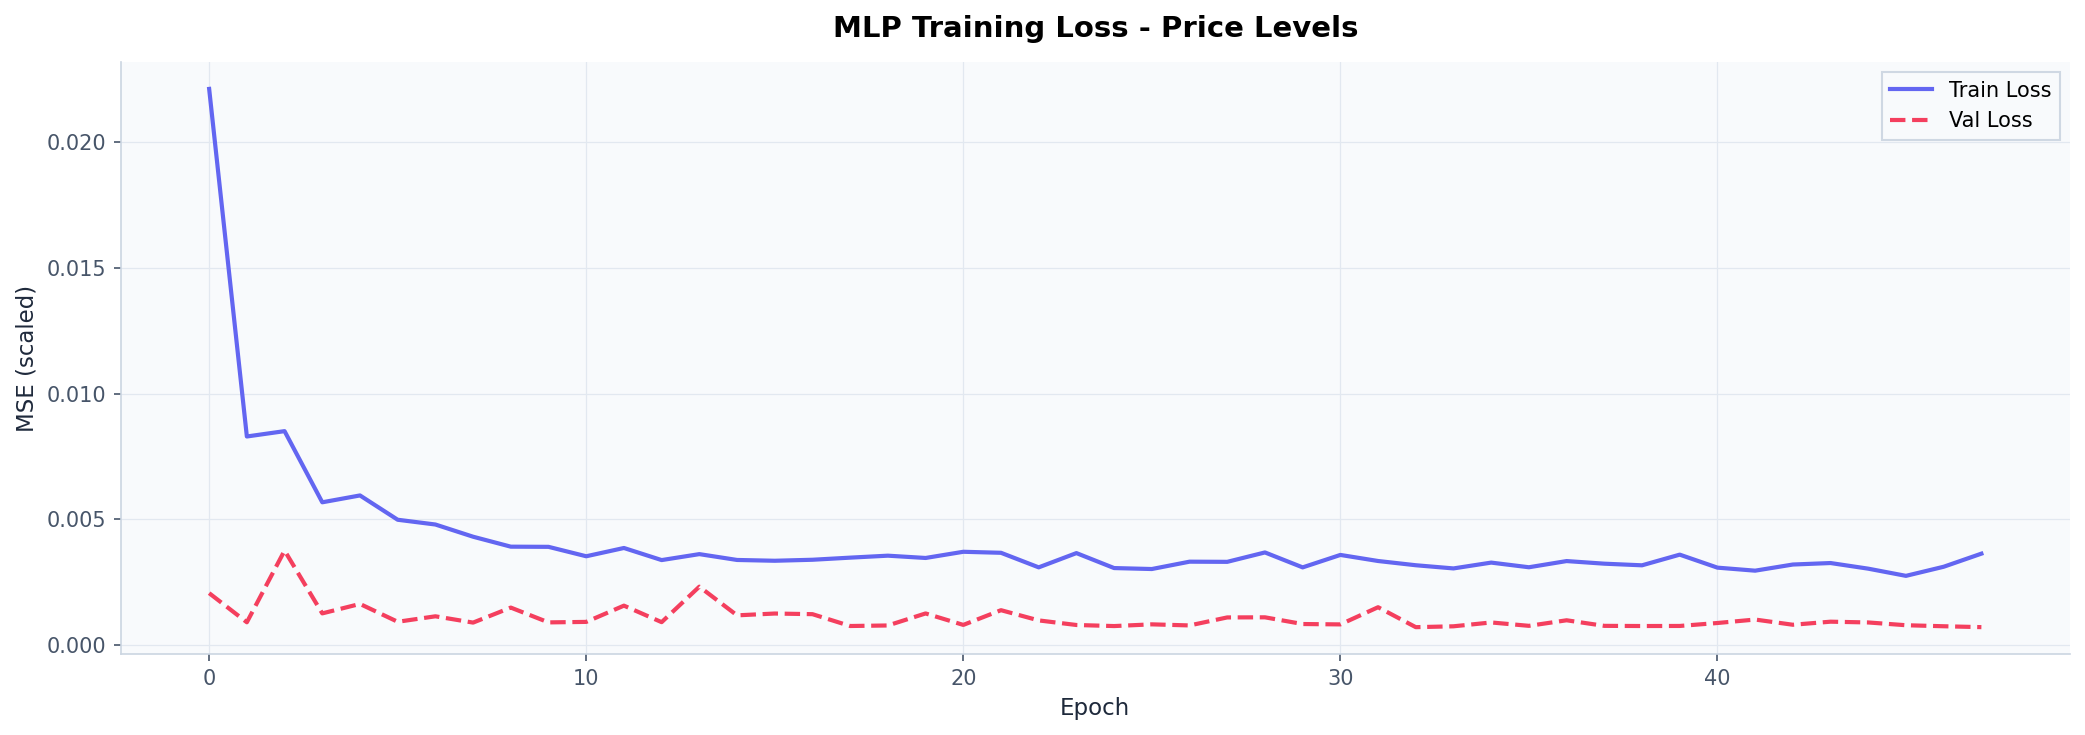

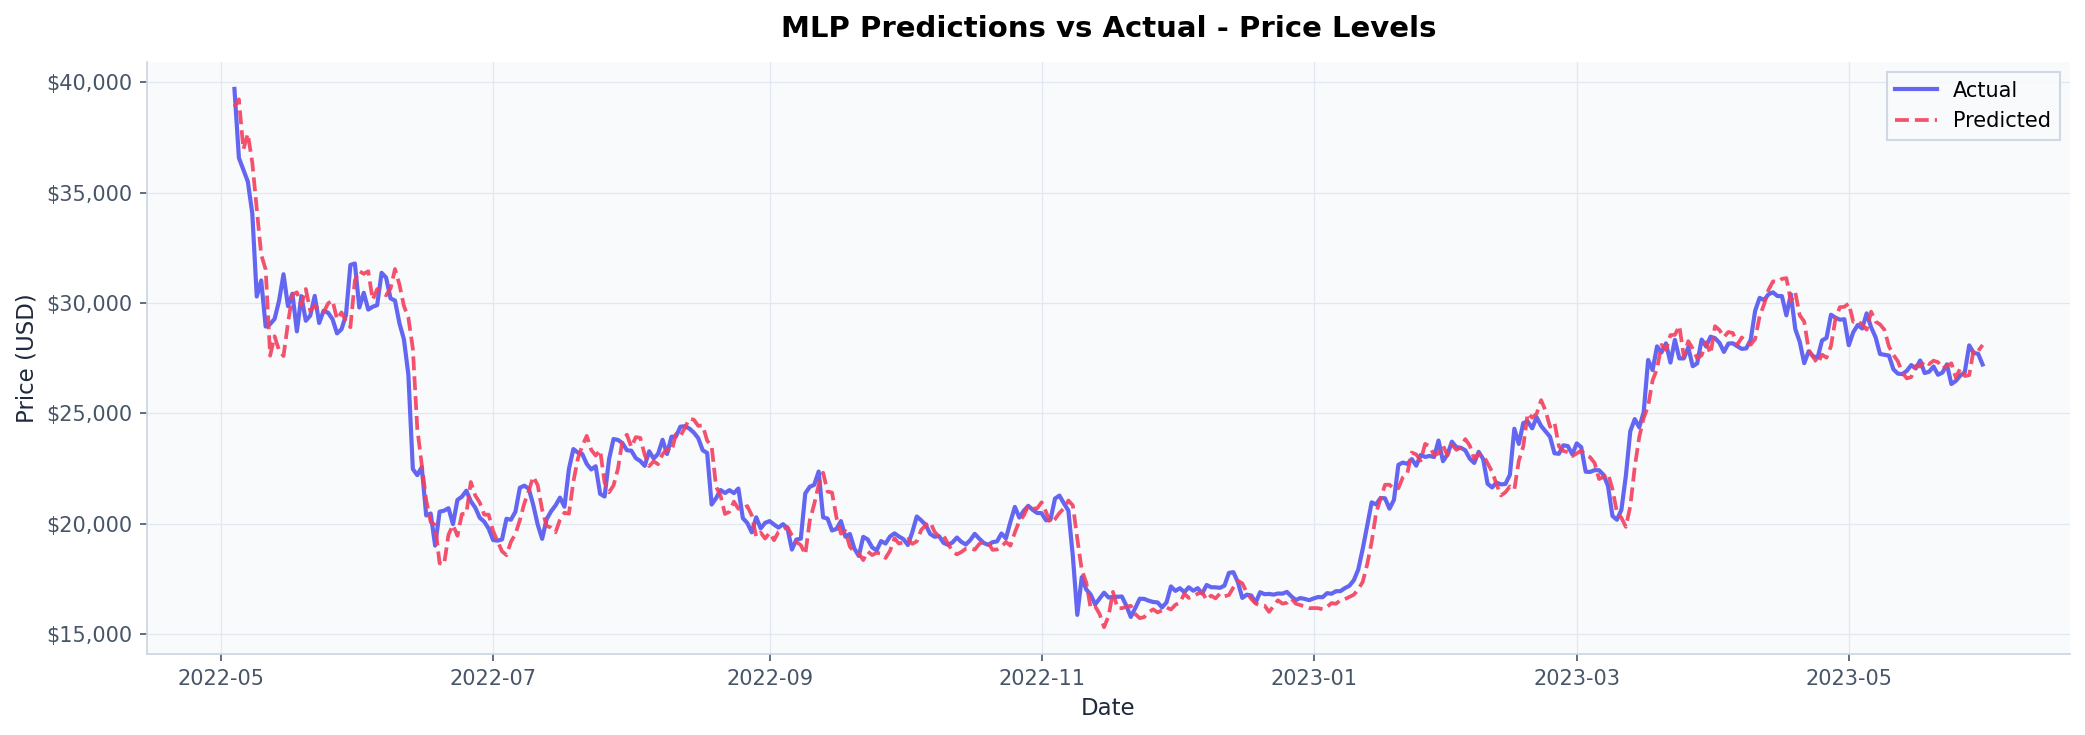

MSE: 995,160.96 | RMSE: 997.58 | MAE: 719.37 | R²: 0.952494


In [15]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(hist_lev.history['loss'],     color=C['indigo'], lw=2,        label='Train Loss')
ax.plot(hist_lev.history['val_loss'], color=C['rose'],   lw=2, ls='--', label='Val Loss')
ax.set_title('MLP Training Loss - Price Levels')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)'); ax.legend()
plt.tight_layout(); plt.show()

y_pred_lev_sc = mlp_lev.predict(X_te_lev_sc, verbose=0).ravel()
y_pred_lev    = sc_lev_y.inverse_transform(y_pred_lev_sc.reshape(-1, 1)).ravel()


y_te_lev_plot  = y_te_lev

y_pred_lev     = y_pred_lev[:len(y_te_lev_plot)]

lev_test_index = close.index[split + MLP_WINDOW : split + MLP_WINDOW + len(y_te_lev_plot)]

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(lev_test_index, y_te_lev_plot, color=C['indigo'], lw=2,        label='Actual')
ax.plot(lev_test_index, y_pred_lev,    color=C['rose'],   lw=1.8, ls='--', label='Predicted', alpha=0.9)
ax.set_title('MLP Predictions vs Actual - Price Levels')
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout(); plt.show()

mse_l  = mean_squared_error(y_te_lev_plot, y_pred_lev)
rmse_l = np.sqrt(mse_l)
mae_l  = mean_absolute_error(y_te_lev_plot, y_pred_lev)
r2_l   = r2_score(y_te_lev_plot, y_pred_lev)
print(f"MSE: {mse_l:,.2f} | RMSE: {rmse_l:,.2f} | MAE: {mae_l:,.2f} | R²: {r2_l:.6f}")
mlp_metrics['Levels'] = dict(MSE=mse_l, RMSE=rmse_l, MAE=mae_l, R2=r2_l)

### MLP on Log-Returns

MLP - LOG-RETURNS
Best epoch: 1


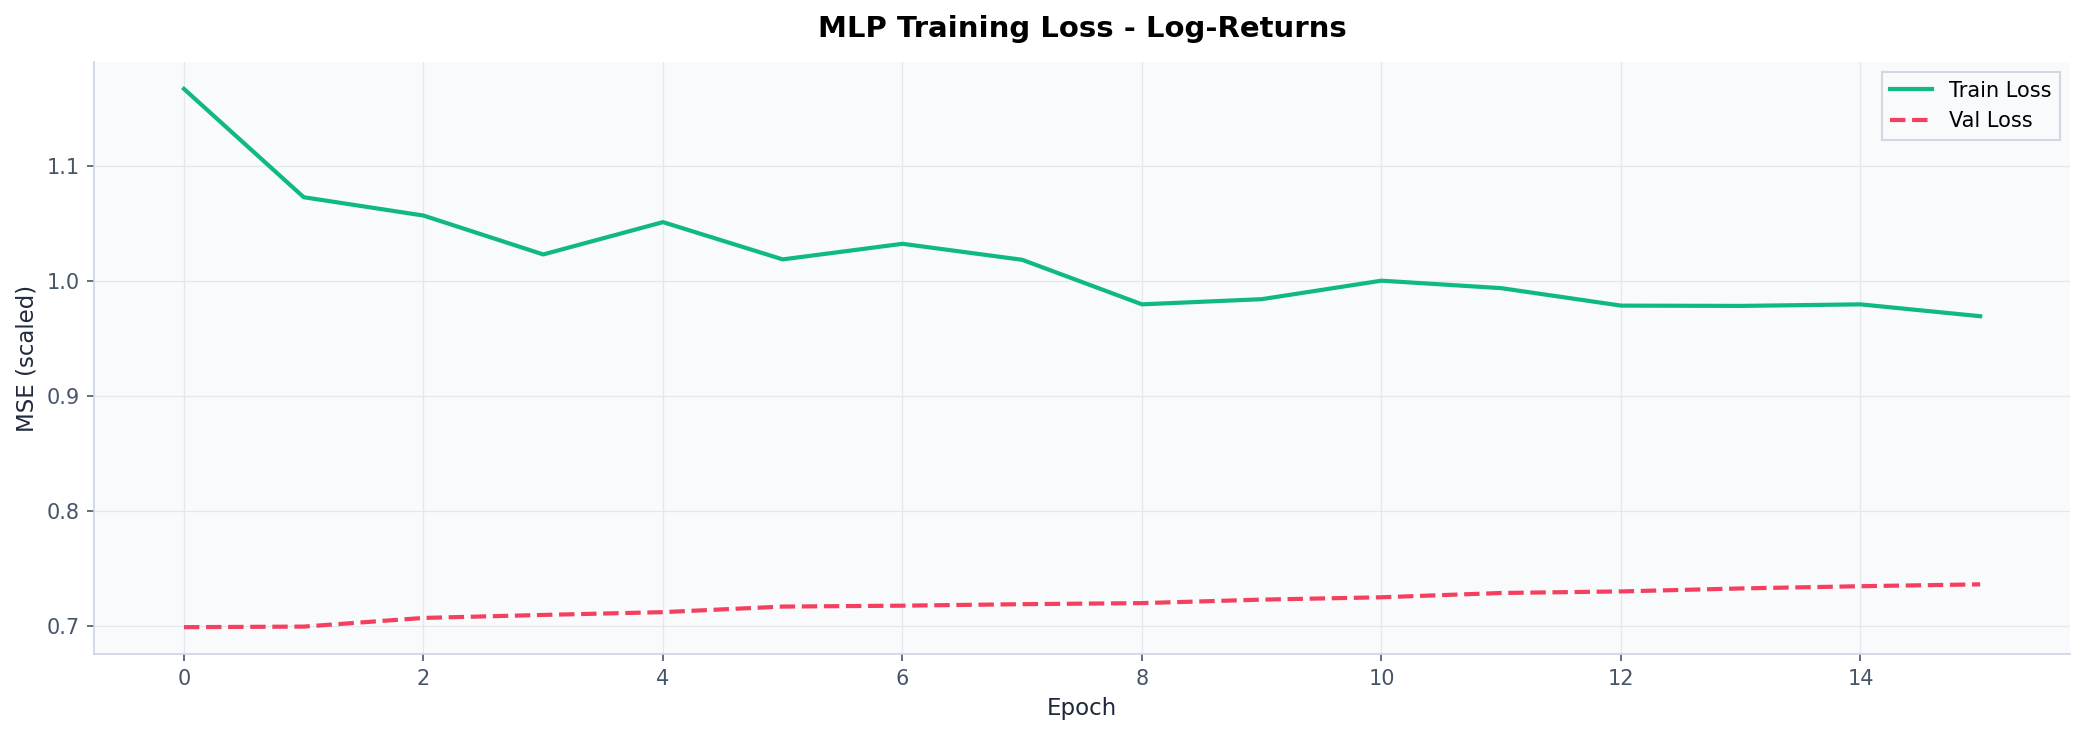

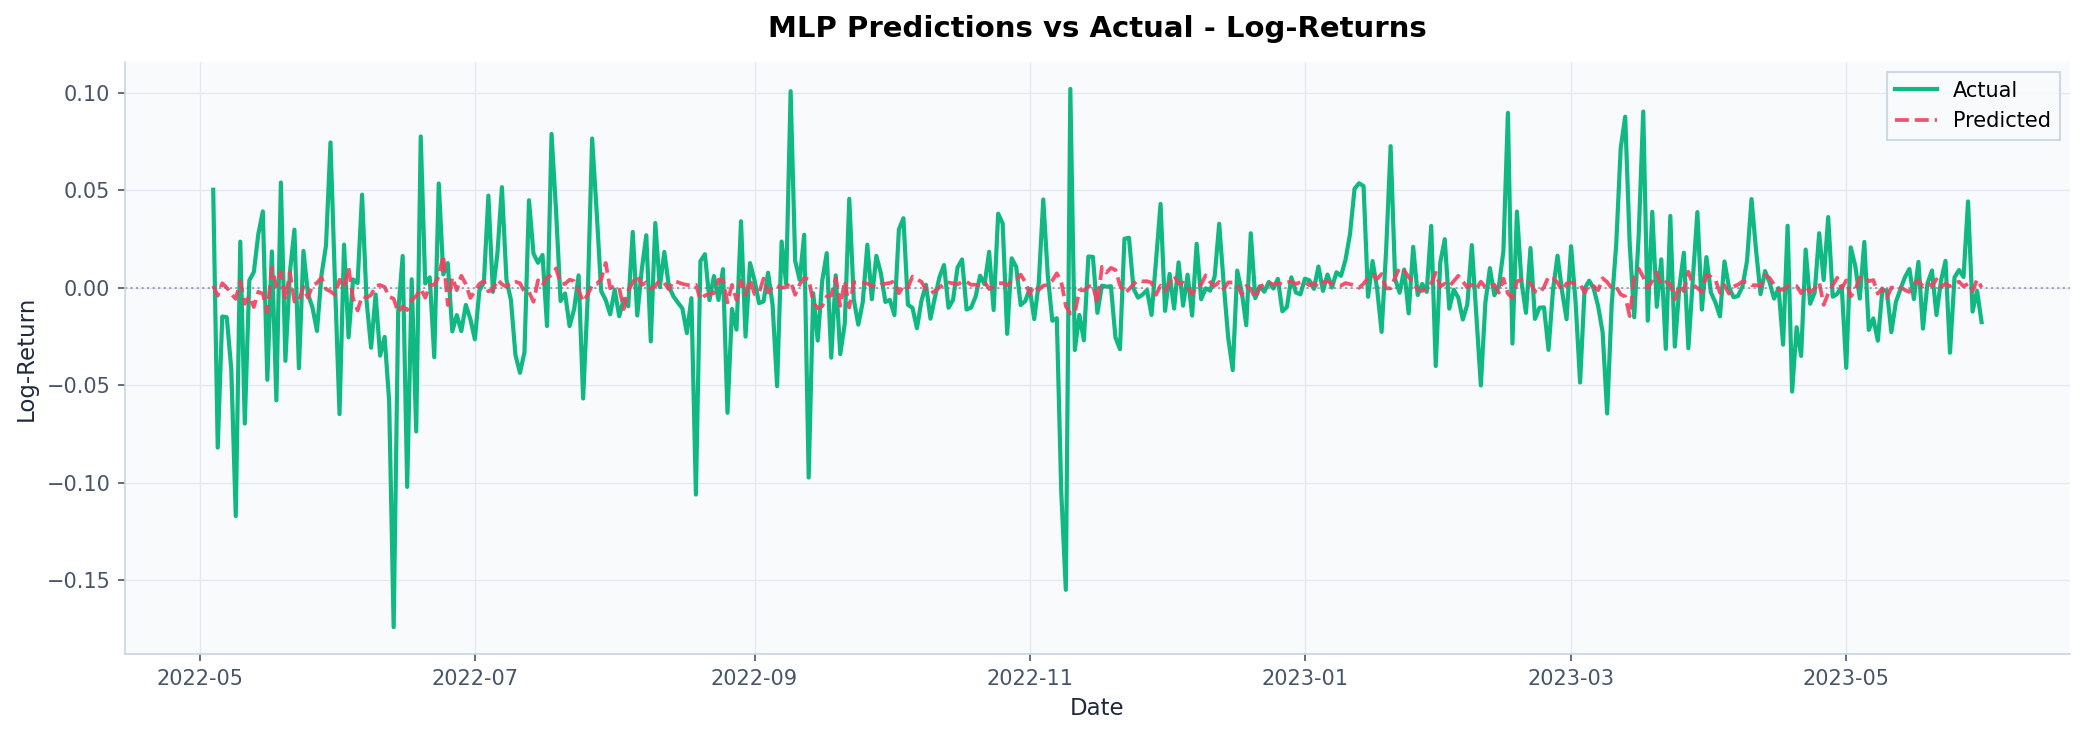

MSE: 0.00096199 | RMSE: 0.031016 | MAE: 0.020896 | R²: 0.009814


In [16]:
print("=" * 60)
print("MLP - LOG-RETURNS")
print("=" * 60)

X_lr, y_lr          = create_mlp_data(log_returns.values, MLP_WINDOW)
split_lr             = int(TRAIN_RATIO * len(X_lr))
X_tr_lr, X_te_lr    = X_lr[:split_lr], X_lr[split_lr:]
y_tr_lr, y_te_lr    = y_lr[:split_lr], y_lr[split_lr:]

sc_lr_X = StandardScaler(); sc_lr_y = StandardScaler()
X_tr_lr_sc = sc_lr_X.fit_transform(X_tr_lr)
X_te_lr_sc = sc_lr_X.transform(X_te_lr)
y_tr_lr_sc = sc_lr_y.fit_transform(y_tr_lr.reshape(-1, 1)).ravel()
y_te_lr_sc = sc_lr_y.transform(y_te_lr.reshape(-1, 1)).ravel()

mlp_lr = Sequential([
    Dense(64, activation='relu', input_shape=(MLP_WINDOW,)),
    Dropout(0.2), Dense(32, activation='relu'), Dropout(0.2), Dense(1)
])
mlp_lr.compile(optimizer=tf.keras.optimizers.Adam(LR), loss='mse')

hist_lr = mlp_lr.fit(X_tr_lr_sc, y_tr_lr_sc,
                      epochs=MLP_EPOCHS, batch_size=BATCH_SIZE,
                      validation_split=VAL_SPLIT,
                      callbacks=make_callbacks(MLP_PATIENCE, MLP_PATIENCE // 2), verbose=0)
print(f"Best epoch: {np.argmin(hist_lr.history['val_loss']) + 1}")

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(hist_lr.history['loss'],     color=C['emerald'], lw=2,        label='Train Loss')
ax.plot(hist_lr.history['val_loss'], color=C['rose'],    lw=2, ls='--', label='Val Loss')
ax.set_title('MLP Training Loss - Log-Returns')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)'); ax.legend()
plt.tight_layout(); plt.show()

y_pred_lr_sc = mlp_lr.predict(X_te_lr_sc, verbose=0).ravel()
y_pred_lr    = sc_lr_y.inverse_transform(y_pred_lr_sc.reshape(-1, 1)).ravel()

actual_test_length = len(y_te_lr)

y_pred_lr = y_pred_lr[:actual_test_length]

y_te_lr_plot = y_te_lr[:actual_test_length]

lr_test_index = log_returns.index[split_lr + MLP_WINDOW : split_lr + MLP_WINDOW + actual_test_length]

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(lr_test_index, y_te_lr_plot, color=C['emerald'], lw=2,        label='Actual')
ax.plot(lr_test_index, y_pred_lr,    color=C['rose'],    lw=1.8, ls='--', label='Predicted', alpha=0.9)
ax.axhline(0, color=C['slate'], ls=':', lw=1, alpha=0.6)
ax.set_title('MLP Predictions vs Actual - Log-Returns')
ax.set_xlabel('Date'); ax.set_ylabel('Log-Return'); ax.legend()
plt.tight_layout(); plt.show()

mse_lr  = mean_squared_error(y_te_lr_plot, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr  = mean_absolute_error(y_te_lr_plot, y_pred_lr)
r2_lr   = r2_score(y_te_lr_plot, y_pred_lr)
print(f"MSE: {mse_lr:.8f} | RMSE: {rmse_lr:.6f} | MAE: {mae_lr:.6f} | R²: {r2_lr:.6f}")
mlp_metrics['Log-Returns'] = dict(MSE=mse_lr, RMSE=rmse_lr, MAE=mae_lr, R2=r2_lr)

### MLP on Fractionally Differenced Series

MLP — FRACTIONALLY DIFFERENCED
Best epoch: 6


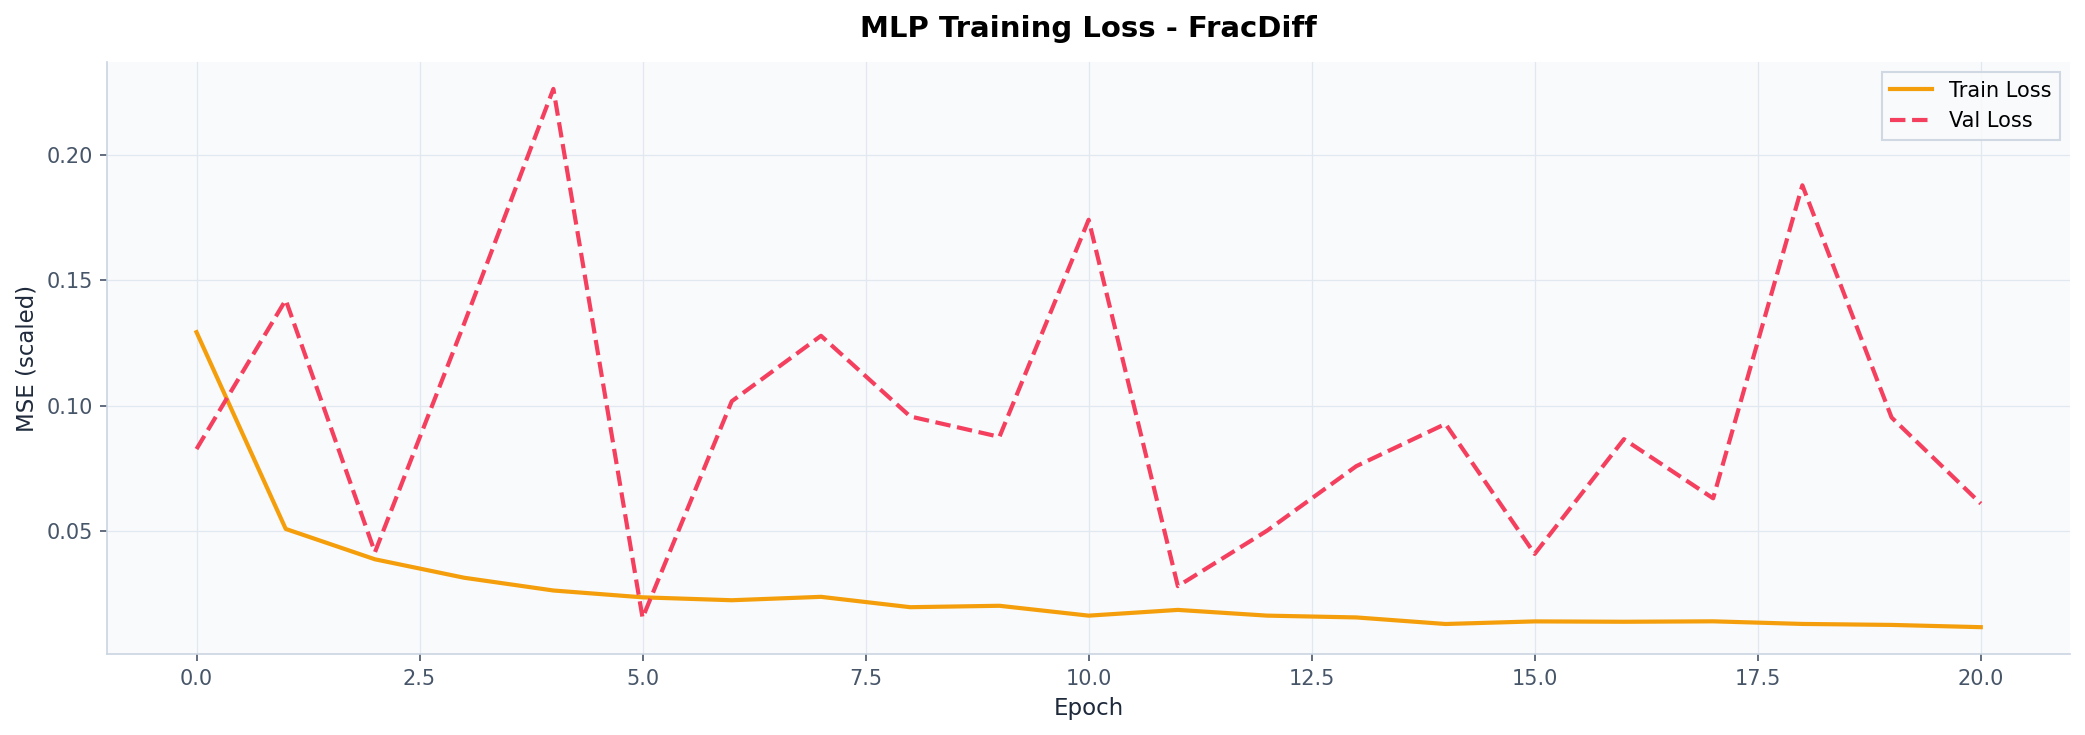

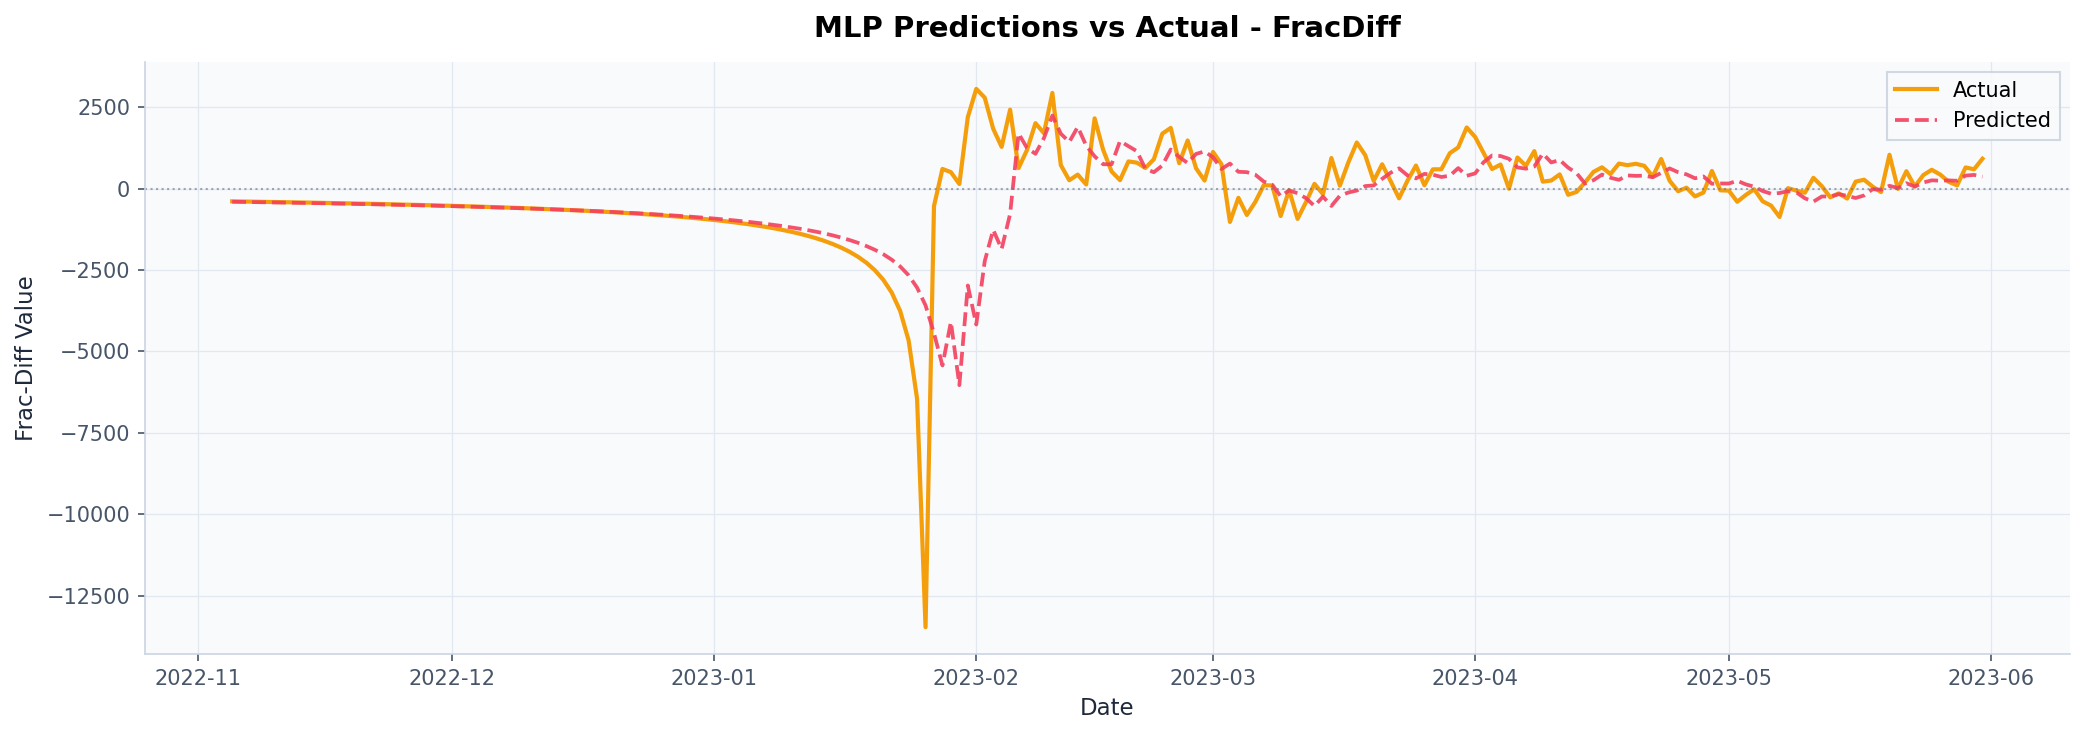

MSE: 1964783.56727945 | RMSE: 1401.707376 | MAE: 607.777097 | R²: 0.085608


In [18]:
print("=" * 60)
print("MLP — FRACTIONALLY DIFFERENCED")
print("=" * 60)

X_fd, y_fd          = create_mlp_data(frac_diff_series.values, MLP_WINDOW)
split_fd             = int(TRAIN_RATIO * len(X_fd))
X_tr_fd, X_te_fd    = X_fd[:split_fd], X_fd[split_fd:]
y_tr_fd, y_te_fd    = y_fd[:split_fd], y_fd[split_fd:]

sc_fd_X = StandardScaler(); sc_fd_y = StandardScaler()
X_tr_fd_sc = sc_fd_X.fit_transform(X_tr_fd)
X_te_fd_sc = sc_fd_X.transform(X_te_fd)
y_tr_fd_sc = sc_fd_y.fit_transform(y_tr_fd.reshape(-1, 1)).ravel()
y_te_fd_sc = sc_fd_y.transform(y_te_fd.reshape(-1, 1)).ravel()

mlp_fd = Sequential([
    Dense(64, activation='relu', input_shape=(MLP_WINDOW,)),
    Dropout(0.2), Dense(32, activation='relu'), Dropout(0.2), Dense(1)
])
mlp_fd.compile(optimizer=tf.keras.optimizers.Adam(LR), loss='mse')

hist_fd = mlp_fd.fit(X_tr_fd_sc, y_tr_fd_sc,
                      epochs=MLP_EPOCHS, batch_size=BATCH_SIZE,
                      validation_split=VAL_SPLIT,
                      callbacks=make_callbacks(MLP_PATIENCE, MLP_PATIENCE // 2), verbose=0)
print(f"Best epoch: {np.argmin(hist_fd.history['val_loss']) + 1}")

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(hist_fd.history['loss'],     color=C['amber'], lw=2,        label='Train Loss')
ax.plot(hist_fd.history['val_loss'], color=C['rose'],  lw=2, ls='--', label='Val Loss')
ax.set_title('MLP Training Loss - FracDiff')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)'); ax.legend()
plt.tight_layout(); plt.show()

y_pred_fd_sc = mlp_fd.predict(X_te_fd_sc, verbose=0).ravel()
y_pred_fd    = sc_fd_y.inverse_transform(y_pred_fd_sc.reshape(-1, 1)).ravel()

actual_test_length = len(y_te_fd)

y_pred_fd = y_pred_fd[:actual_test_length]

y_te_fd_plot = y_te_fd

fd_test_index = frac_diff_series.index[split_fd + MLP_WINDOW : split_fd + MLP_WINDOW + actual_test_length]

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(fd_test_index, y_te_fd_plot, color=C['amber'], lw=2,        label='Actual')
ax.plot(fd_test_index, y_pred_fd,    color=C['rose'],  lw=1.8, ls='--', label='Predicted', alpha=0.9)
ax.axhline(0, color=C['slate'], ls=':', lw=1, alpha=0.6)
ax.set_title('MLP Predictions vs Actual - FracDiff')
ax.set_xlabel('Date'); ax.set_ylabel('Frac-Diff Value'); ax.legend()
plt.tight_layout(); plt.show()

mse_fd  = mean_squared_error(y_te_fd_plot, y_pred_fd)
rmse_fd = np.sqrt(mse_fd)
mae_fd  = mean_absolute_error(y_te_fd_plot, y_pred_fd)
r2_fd   = r2_score(y_te_fd_plot, y_pred_fd)
print(f"MSE: {mse_fd:.8f} | RMSE: {rmse_fd:.6f} | MAE: {mae_fd:.6f} | R²: {r2_fd:.6f}")
mlp_metrics['FracDiff'] = dict(MSE=mse_fd, RMSE=rmse_fd, MAE=mae_fd, R2=r2_fd)

In [ ]:
print("=" * 60)
print("MLP MODELS COMPARISON")
print("=" * 60)
mlp_df = pd.DataFrame(mlp_metrics).T
print(mlp_df.round(6))

MLP MODELS COMPARISON
                      MSE         RMSE         MAE        R2
Levels       9.951610e+05   997.577548  719.368099  0.952494
Log-Returns  9.620000e-04     0.031016    0.020896  0.009814
FracDiff     1.964784e+06  1401.707376  607.777097  0.085608


## CNN with Gramian Angular Field (GAF)

### GAF Transformation - All Three Series

GAF TRANSFORMATION
Creating GAF images for Price Levels ...
  Levels   : (1953, 24, 24), labels (1953,)
Creating GAF images for Log-Returns ...
  Log-Ret  : (1952, 24, 24), labels (1952,)
Creating GAF images for FracDiff ...
  FracDiff : (1027, 24, 24), labels (1027,)


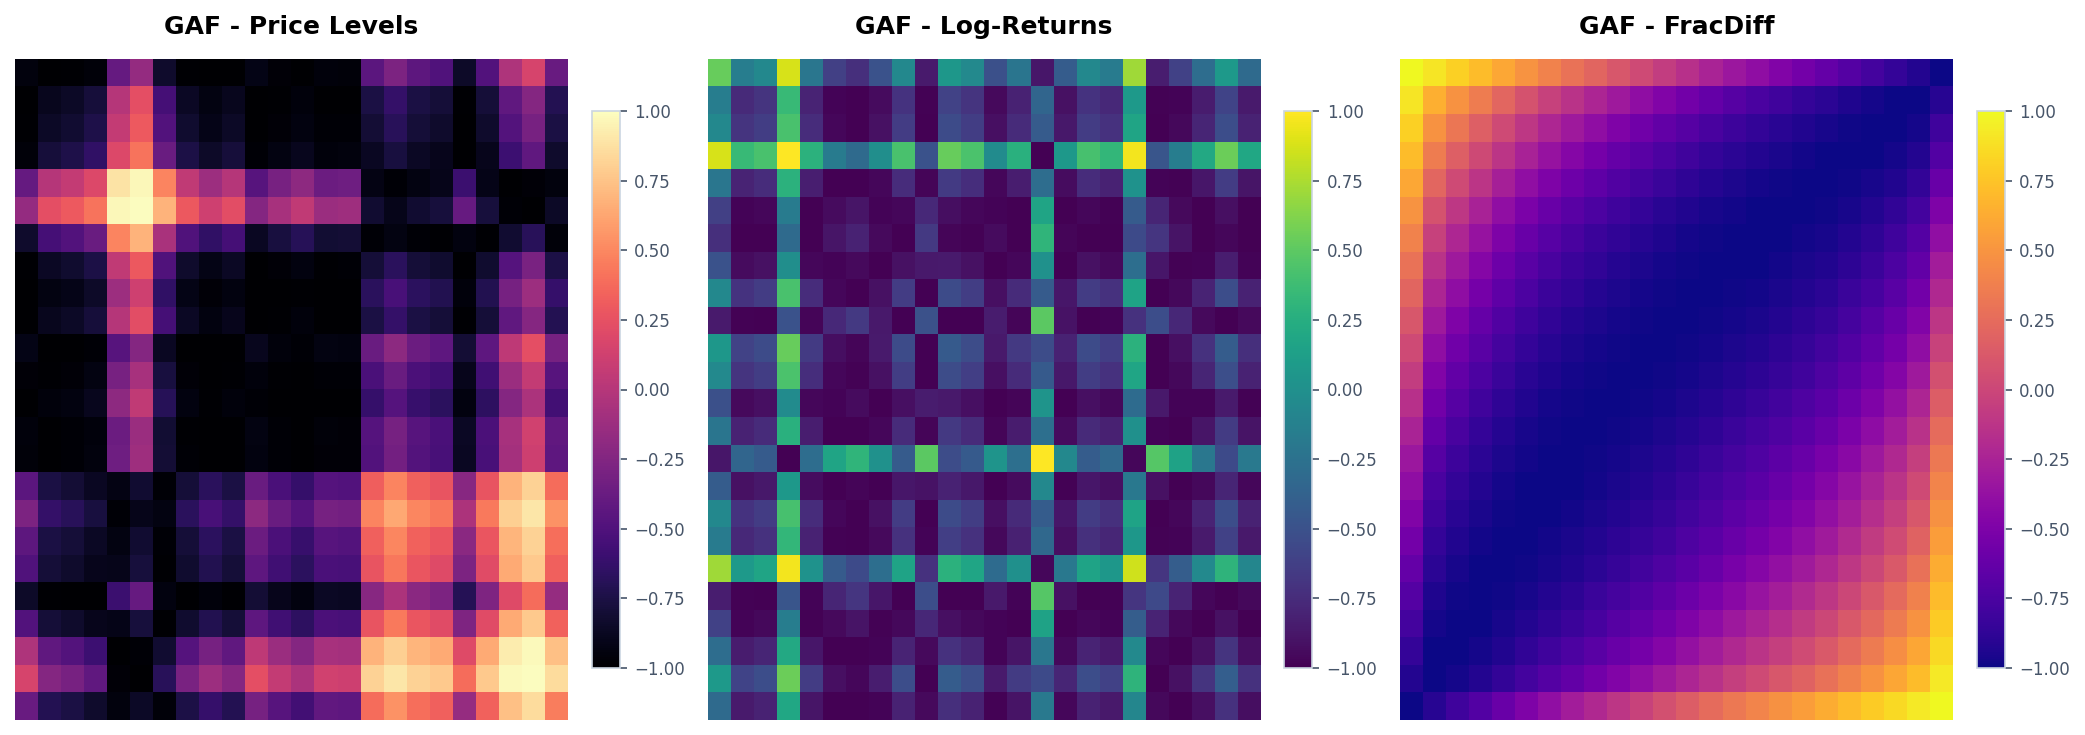

In [19]:
print("=" * 60)
print("GAF TRANSFORMATION")
print("=" * 60)

def create_gaf_dataset(series, window_size):
    n = len(series)
    windows = np.lib.stride_tricks.sliding_window_view(series, window_size)
    labels  = (series[window_size:] > series[window_size - 1 : n - 1]).astype(int)
    windows = windows[:-1]
    gaf     = GramianAngularField(image_size=window_size, method='summation')
    images  = gaf.fit_transform(windows)
    return images, labels

print("Creating GAF images for Price Levels ...")
X_gaf_lev, y_gaf_lev = create_gaf_dataset(close.values,            GAF_WINDOW)
print(f"  Levels   : {X_gaf_lev.shape}, labels {y_gaf_lev.shape}")

print("Creating GAF images for Log-Returns ...")
X_gaf_lr,  y_gaf_lr  = create_gaf_dataset(log_returns.values,      GAF_WINDOW)
print(f"  Log-Ret  : {X_gaf_lr.shape}, labels {y_gaf_lr.shape}")

print("Creating GAF images for FracDiff ...")
X_gaf_fd,  y_gaf_fd  = create_gaf_dataset(frac_diff_series.values, GAF_WINDOW)
print(f"  FracDiff : {X_gaf_fd.shape}, labels {y_gaf_fd.shape}")

fig, axes = plt.subplots(1, 3, figsize=FIG_3COL)
samples = [X_gaf_lev[0], X_gaf_lr[0], X_gaf_fd[0]]
titles  = ['GAF - Price Levels', 'GAF - Log-Returns', 'GAF - FracDiff']
cmaps   = ['magma', 'viridis', 'plasma']
for ax, img, title, cmap in zip(axes, samples, titles, cmaps):
    im = ax.imshow(img, cmap=cmap, aspect='auto', interpolation='nearest')
    ax.set_title(title, fontsize=12); ax.axis('off')
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

### CNN on Price Levels (GAF)

In [20]:
cnn_metrics = {}

def build_cnn(input_shape=(GAF_WINDOW, GAF_WINDOW, 1)):
    """
    CNN with BatchNormalization and padding='same'.
    FIX: original had no BatchNorm; padding='valid' shrinks 24x24 images fast.
    """
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(LR),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

print("=" * 60)
print("CNN - PRICE LEVELS (GAF)")
print("=" * 60)

X_cnn_lev = X_gaf_lev.reshape(-1, GAF_WINDOW, GAF_WINDOW, 1)
sp_cnn    = int(TRAIN_RATIO * len(X_cnn_lev))
X_tr_cl, X_te_cl = X_cnn_lev[:sp_cnn], X_cnn_lev[sp_cnn:]
y_tr_cl, y_te_cl = y_gaf_lev[:sp_cnn], y_gaf_lev[sp_cnn:]

print(f"Train: {len(X_tr_cl)} | Test: {len(X_te_cl)}")
print(f"Class distribution - Train: {np.bincount(y_tr_cl)} | Test: {np.bincount(y_te_cl)}")

cnn_lev = build_cnn()
cnn_lev.summary()

hist_cl = cnn_lev.fit(X_tr_cl, y_tr_cl,
                       epochs=CNN_EPOCHS, batch_size=BATCH_SIZE,
                       validation_split=VAL_SPLIT,
                       callbacks=make_callbacks(CNN_PATIENCE, CNN_PATIENCE//2),
                       verbose=0)
print(f"Best epoch: {np.argmin(hist_cl.history['val_loss']) + 1}")

CNN - PRICE LEVELS (GAF)
Train: 1562 | Test: 391
Class distribution - Train: [743 819] | Test: [208 183]


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,785 (651.50 KB)

 Trainable params: 166,593 (650.75 KB)

 Non-trainable params: 192 (768.00 B)

Best epoch: 1


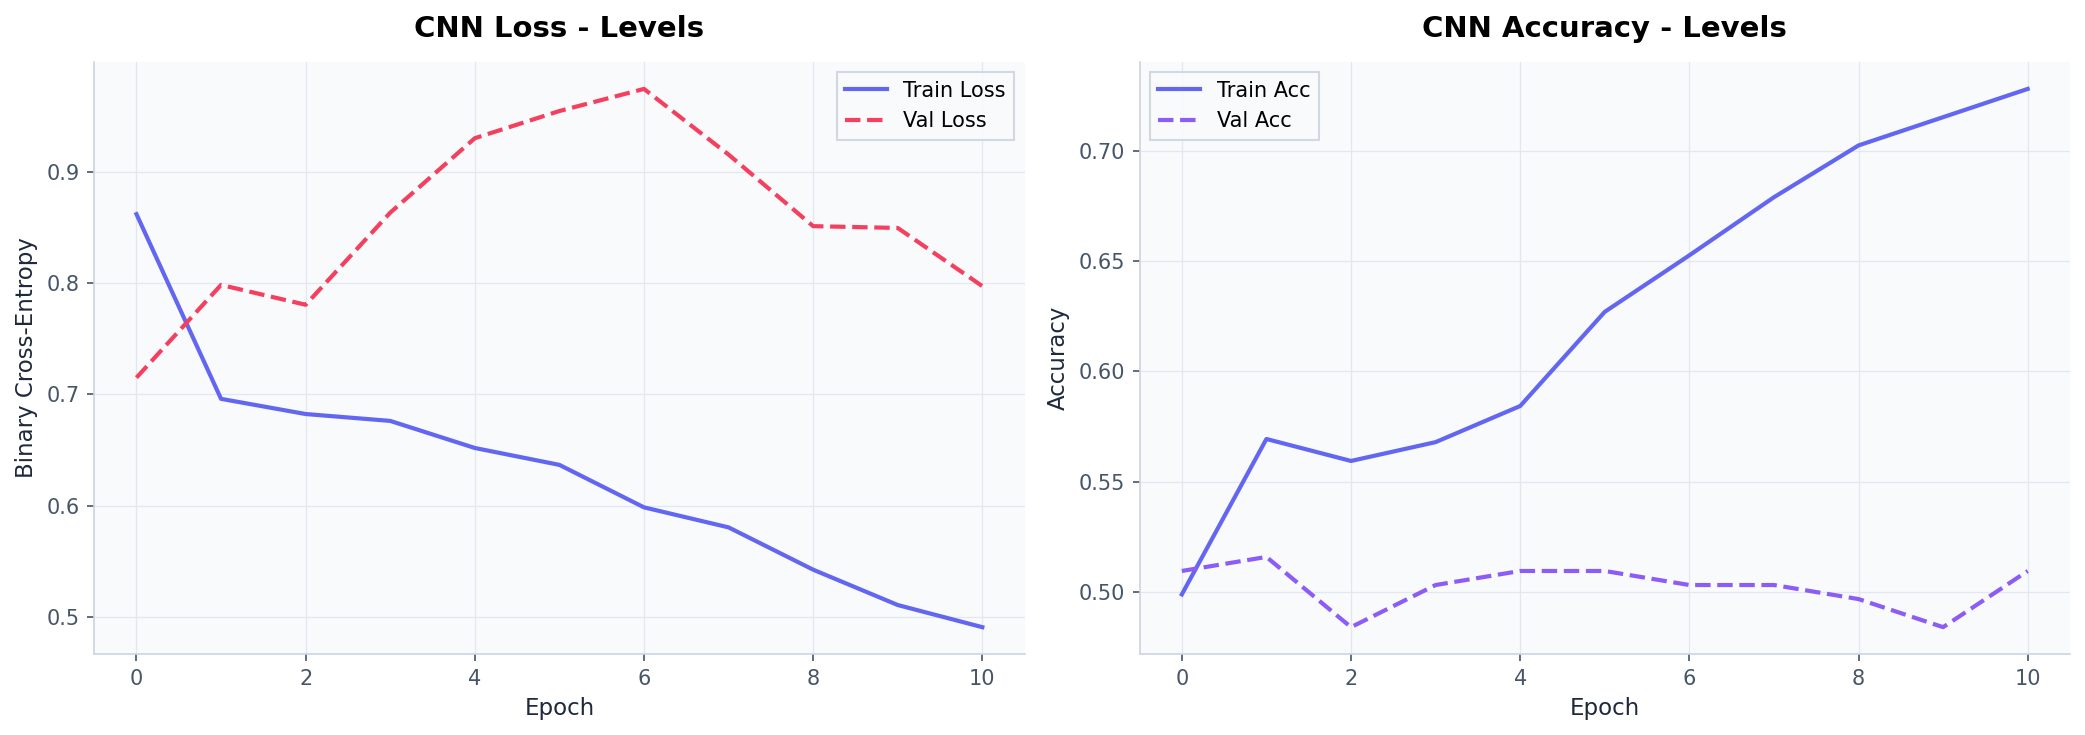

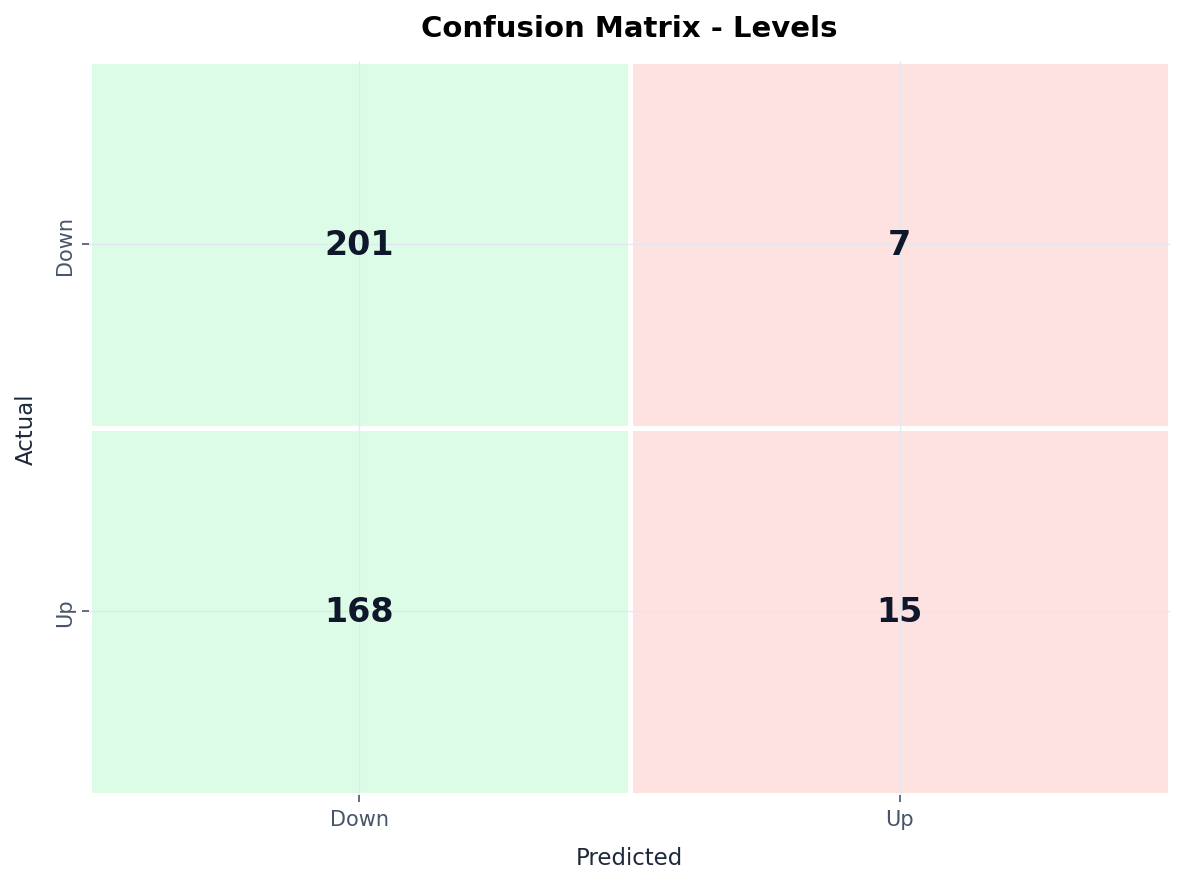

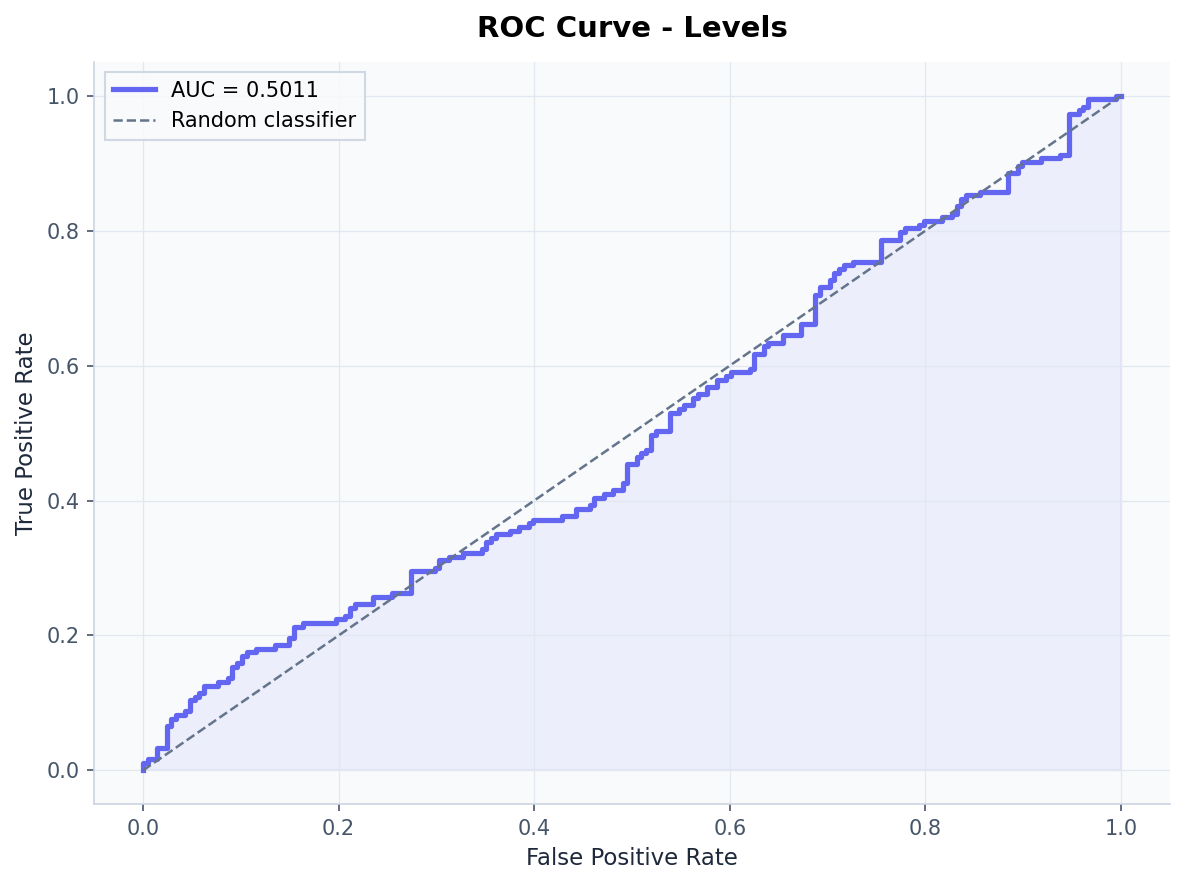

Acc: 0.5524 | Prec: 0.6818 | Rec: 0.0820 | F1: 0.1463 | AUC: 0.5011


In [21]:
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
axes[0].plot(hist_cl.history['loss'],         color=C['indigo'], lw=2,   label='Train Loss')
axes[0].plot(hist_cl.history['val_loss'],     color=C['rose'],       lw=2, ls='--', label='Val Loss')
axes[0].set_title('CNN Loss - Levels')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy'); axes[0].legend()

axes[1].plot(hist_cl.history['accuracy'],     color=C['indigo'], lw=2,   label='Train Acc')
axes[1].plot(hist_cl.history['val_accuracy'], color=C['violet'],     lw=2, ls='--', label='Val Acc')
axes[1].set_title('CNN Accuracy - Levels')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

y_prob_cl = cnn_lev.predict(X_te_cl, verbose=0).ravel()
y_pred_cl = (y_prob_cl > 0.5).astype(int)

y_te_cl_aligned = y_te_cl[:len(y_pred_cl)]

y_prob_cl_aligned = y_prob_cl[:len(y_pred_cl)]

cm = confusion_matrix(y_te_cl_aligned, y_pred_cl)
fig, ax = plt.subplots(figsize=FIG_SQ)
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            cmap=sns.color_palette(["#FEE2E2","#DCFCE7"], as_cmap=True),
            annot_kws={'size': 16, 'weight': 'bold'},
            xticklabels=['Down','Up'], yticklabels=['Down','Up'],
            linewidths=1.5, linecolor='white', cbar=False)
ax.set_title('Confusion Matrix - Levels')
ax.set_xlabel('Predicted', labelpad=8); ax.set_ylabel('Actual', labelpad=8)
for t in ax.texts:
    val = int(t.get_text())
    t.set_color(C['dark'])
plt.tight_layout(); plt.show()

fpr_, tpr_, _ = roc_curve(y_te_cl_aligned, y_prob_cl_aligned)
auc_ = roc_auc_score(y_te_cl_aligned, y_prob_cl_aligned)
fig, ax = plt.subplots(figsize=FIG_SQ)
ax.plot(fpr_, tpr_, color=C['indigo'], lw=2.5, label=f'AUC = {auc_:.4f}')
ax.fill_between(fpr_, tpr_, alpha=0.08, color=C['indigo'])
ax.plot([0,1],[0,1], color=C['slate'], lw=1.2, ls='--', label='Random classifier')
ax.set_title('ROC Curve - Levels')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(); plt.tight_layout(); plt.show()

acc_  = accuracy_score(y_te_cl_aligned, y_pred_cl)
prec_ = precision_score(y_te_cl_aligned, y_pred_cl)
rec_  = recall_score(y_te_cl_aligned, y_pred_cl)
f1_   = f1_score(y_te_cl_aligned, y_pred_cl)
print(f"Acc: {acc_:.4f} | Prec: {prec_:.4f} | Rec: {rec_:.4f} | F1: {f1_:.4f} | AUC: {auc_:.4f}")
cnn_metrics['Levels'] = dict(Accuracy=acc_, Precision=prec_, Recall=rec_, F1=f1_, AUC=auc_)

### CNN on Log-Returns (GAF)

CNN - LOG-RETURNS (GAF)
Train: 1561 | Test: 391
Class distribution - Train: [794 767] | Test: [193 198]
Best epoch: 1


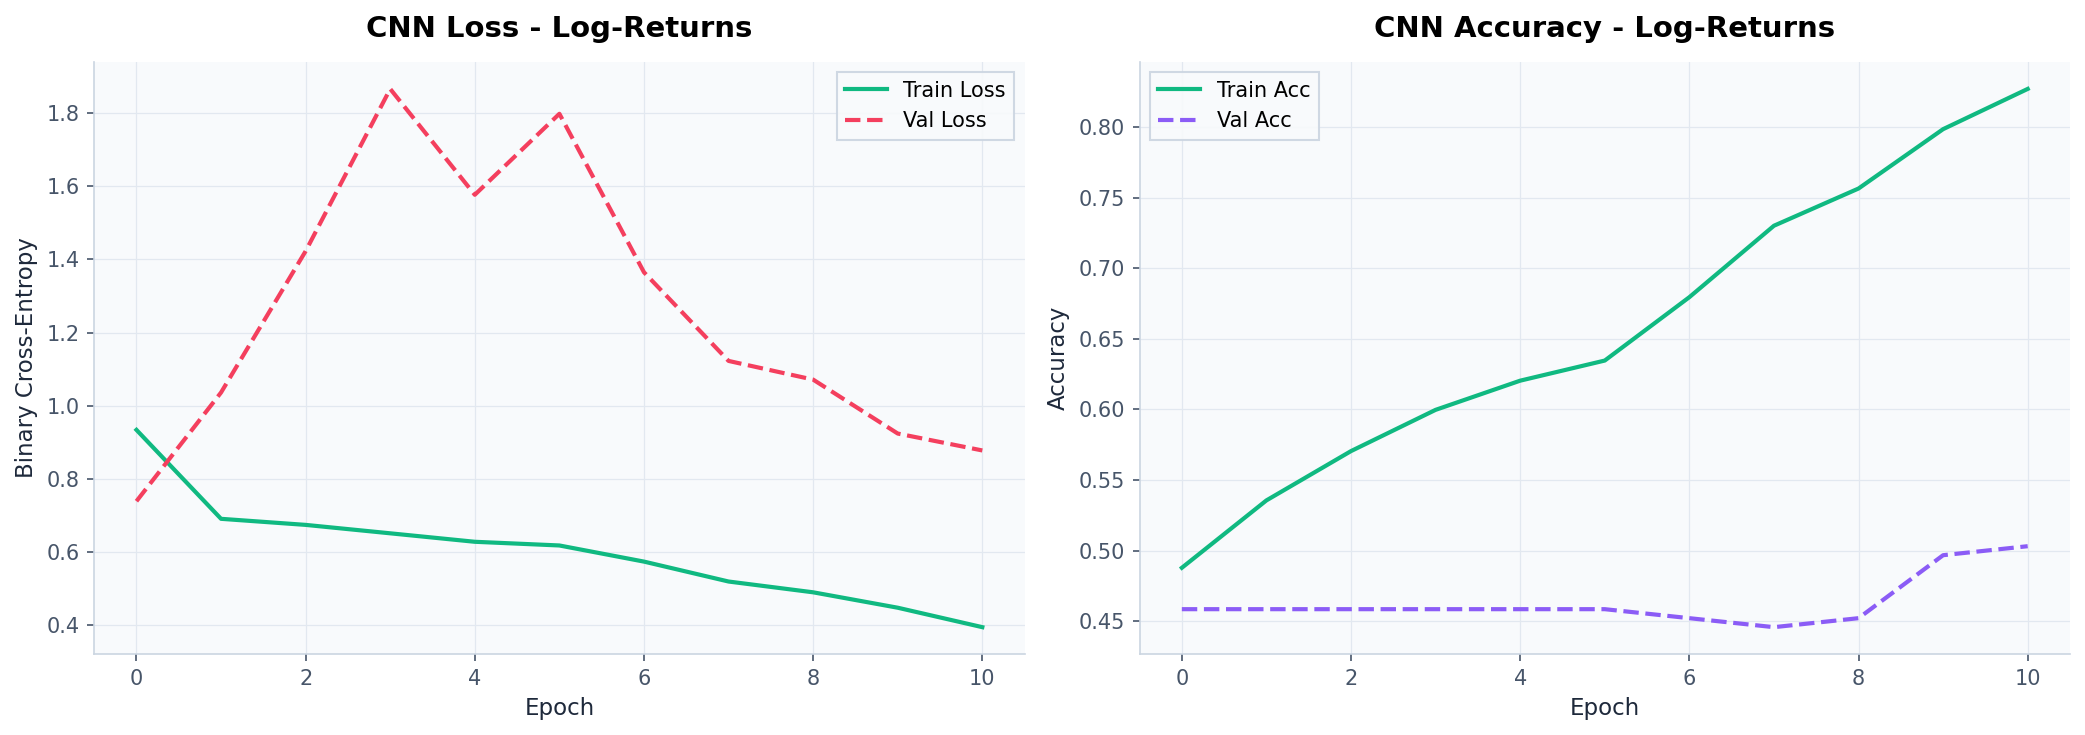

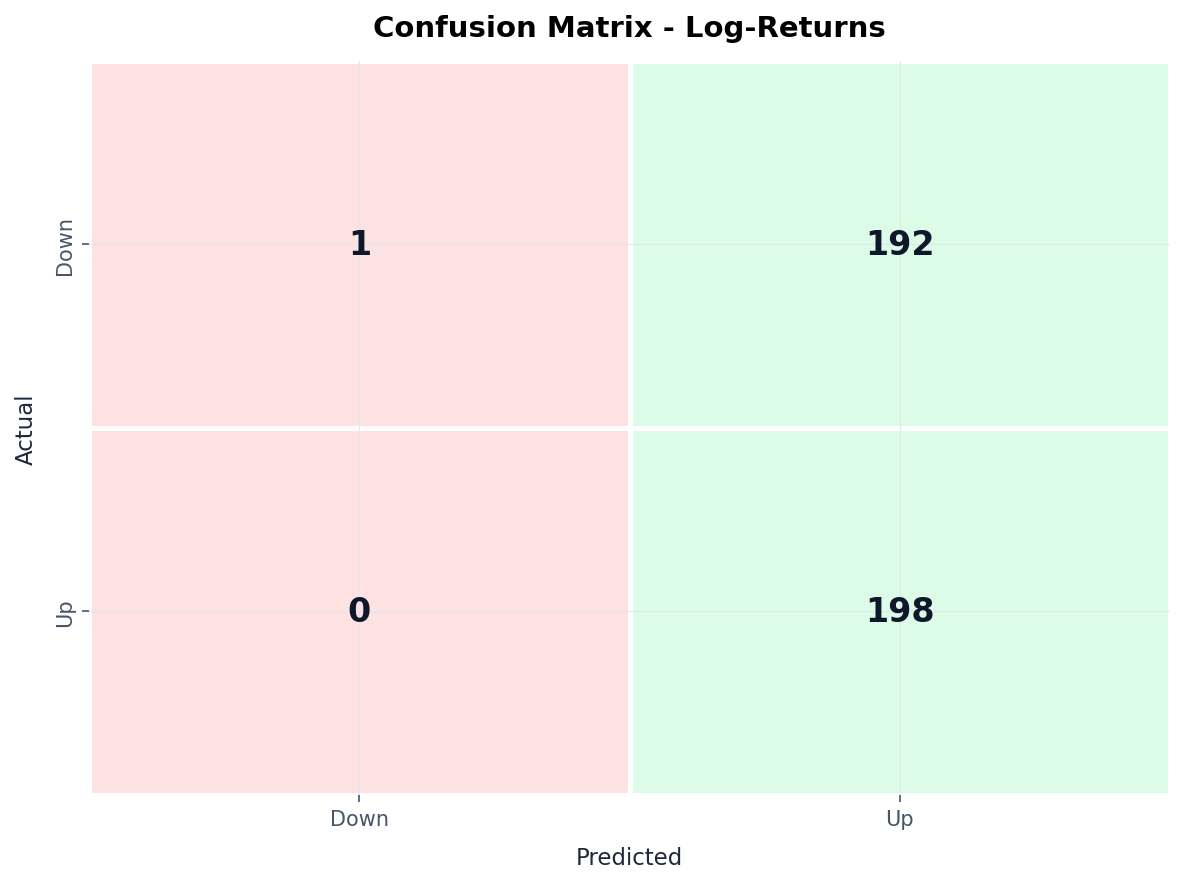

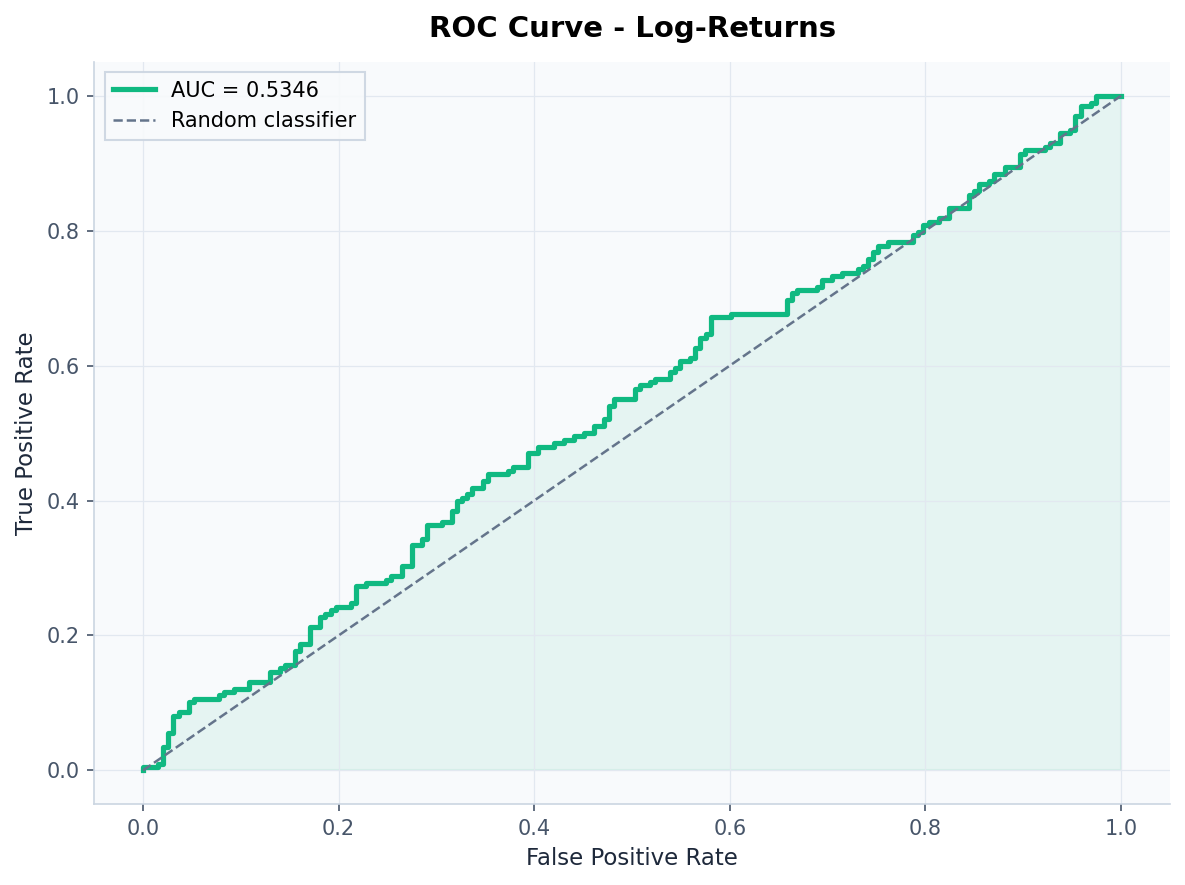

Acc: 0.5090 | Prec: 0.5077 | Rec: 1.0000 | F1: 0.6735 | AUC: 0.5346


In [24]:
print("=" * 60)
print("CNN - LOG-RETURNS (GAF)")
print("=" * 60)

X_cnn_lr = X_gaf_lr.reshape(-1, GAF_WINDOW, GAF_WINDOW, 1)
sp_cnn_lr = int(TRAIN_RATIO * len(X_cnn_lr))
X_tr_clr, X_te_clr = X_cnn_lr[:sp_cnn_lr], X_cnn_lr[sp_cnn_lr:]
y_tr_clr, y_te_clr = y_gaf_lr[:sp_cnn_lr], y_gaf_lr[sp_cnn_lr:]

print(f"Train: {len(X_tr_clr)} | Test: {len(X_te_clr)}")
print(f"Class distribution - Train: {np.bincount(y_tr_clr)} | Test: {np.bincount(y_te_clr)}")

cnn_lr = build_cnn()
hist_clr = cnn_lr.fit(X_tr_clr, y_tr_clr,
                       epochs=CNN_EPOCHS, batch_size=BATCH_SIZE,
                       validation_split=VAL_SPLIT,
                       callbacks=make_callbacks(CNN_PATIENCE, CNN_PATIENCE//2), verbose=0)
print(f"Best epoch: {np.argmin(hist_clr.history['val_loss']) + 1}")

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
axes[0].plot(hist_clr.history['loss'],         color=C['emerald'], lw=2,   label='Train Loss')
axes[0].plot(hist_clr.history['val_loss'],     color=C['rose'],       lw=2, ls='--', label='Val Loss')
axes[0].set_title('CNN Loss - Log-Returns')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy'); axes[0].legend()

axes[1].plot(hist_clr.history['accuracy'],     color=C['emerald'], lw=2,   label='Train Acc')
axes[1].plot(hist_clr.history['val_accuracy'], color=C['violet'],     lw=2, ls='--', label='Val Acc')
axes[1].set_title('CNN Accuracy - Log-Returns')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

y_prob_clr = cnn_lr.predict(X_te_clr, verbose=0).ravel()
y_pred_clr = (y_prob_clr > 0.5).astype(int)

cm = confusion_matrix(y_te_clr, y_pred_clr)
fig, ax = plt.subplots(figsize=FIG_SQ)
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            cmap=sns.color_palette(["#FEE2E2","#DCFCE7"], as_cmap=True),
            annot_kws={'size': 16, 'weight': 'bold'},
            xticklabels=['Down','Up'], yticklabels=['Down','Up'],
            linewidths=1.5, linecolor='white', cbar=False)
ax.set_title('Confusion Matrix - Log-Returns')
ax.set_xlabel('Predicted', labelpad=8); ax.set_ylabel('Actual', labelpad=8)
for t in ax.texts:
    val = int(t.get_text())
    t.set_color(C['dark'])
plt.tight_layout(); plt.show()

fpr_, tpr_, _ = roc_curve(y_te_clr, y_prob_clr)
auc_ = roc_auc_score(y_te_clr, y_prob_clr)
fig, ax = plt.subplots(figsize=FIG_SQ)
ax.plot(fpr_, tpr_, color=C['emerald'], lw=2.5, label=f'AUC = {auc_:.4f}')
ax.fill_between(fpr_, tpr_, alpha=0.08, color=C['emerald'])
ax.plot([0,1],[0,1], color=C['slate'], lw=1.2, ls='--', label='Random classifier')
ax.set_title('ROC Curve - Log-Returns')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(); plt.tight_layout(); plt.show()

acc_  = accuracy_score(y_te_clr, y_pred_clr)
prec_ = precision_score(y_te_clr, y_pred_clr)
rec_  = recall_score(y_te_clr, y_pred_clr)
f1_   = f1_score(y_te_clr, y_pred_clr)
print(f"Acc: {acc_:.4f} | Prec: {prec_:.4f} | Rec: {rec_:.4f} | F1: {f1_:.4f} | AUC: {auc_:.4f}")
cnn_metrics['Log-Returns'] = dict(Accuracy=acc_, Precision=prec_, Recall=rec_, F1=f1_, AUC=auc_)

### CNN on Fractionally Differenced (GAF)

CNN - FRACTIONALLY DIFFERENCED (GAF)
Train: 821 | Test: 206
Class distribution - Train: [821] | Test: [145  61]
Best epoch: 50


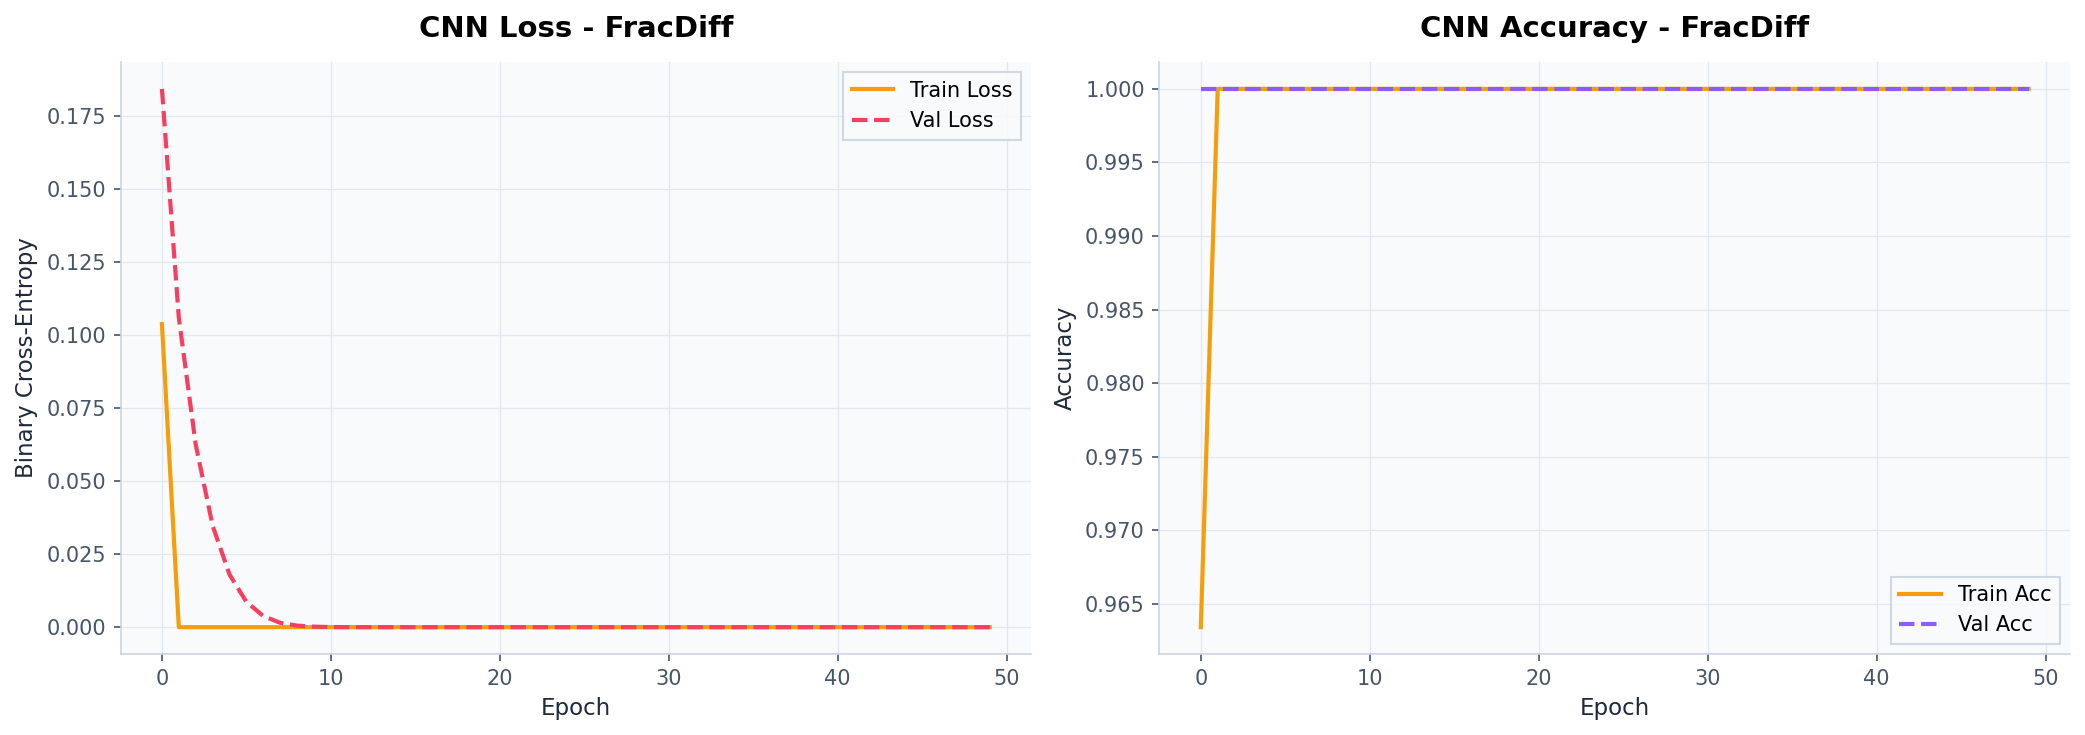

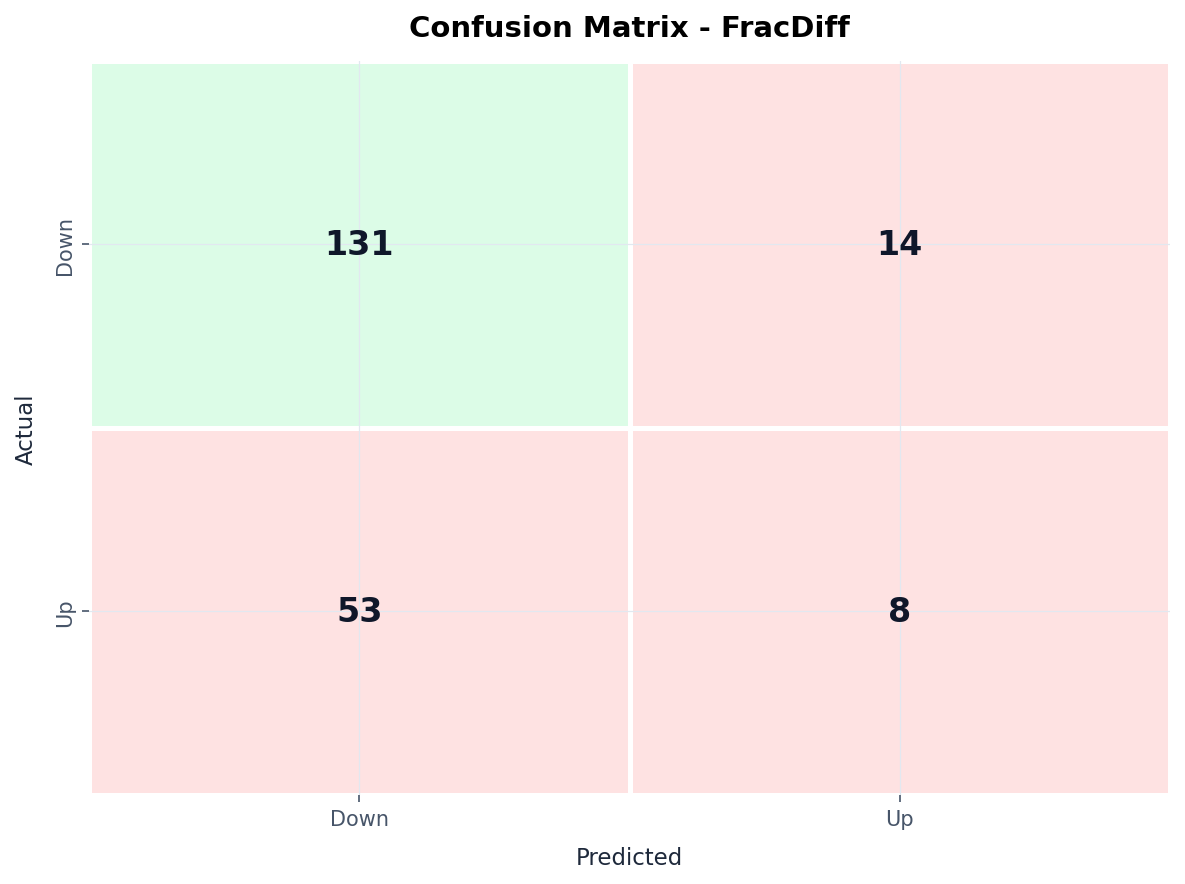

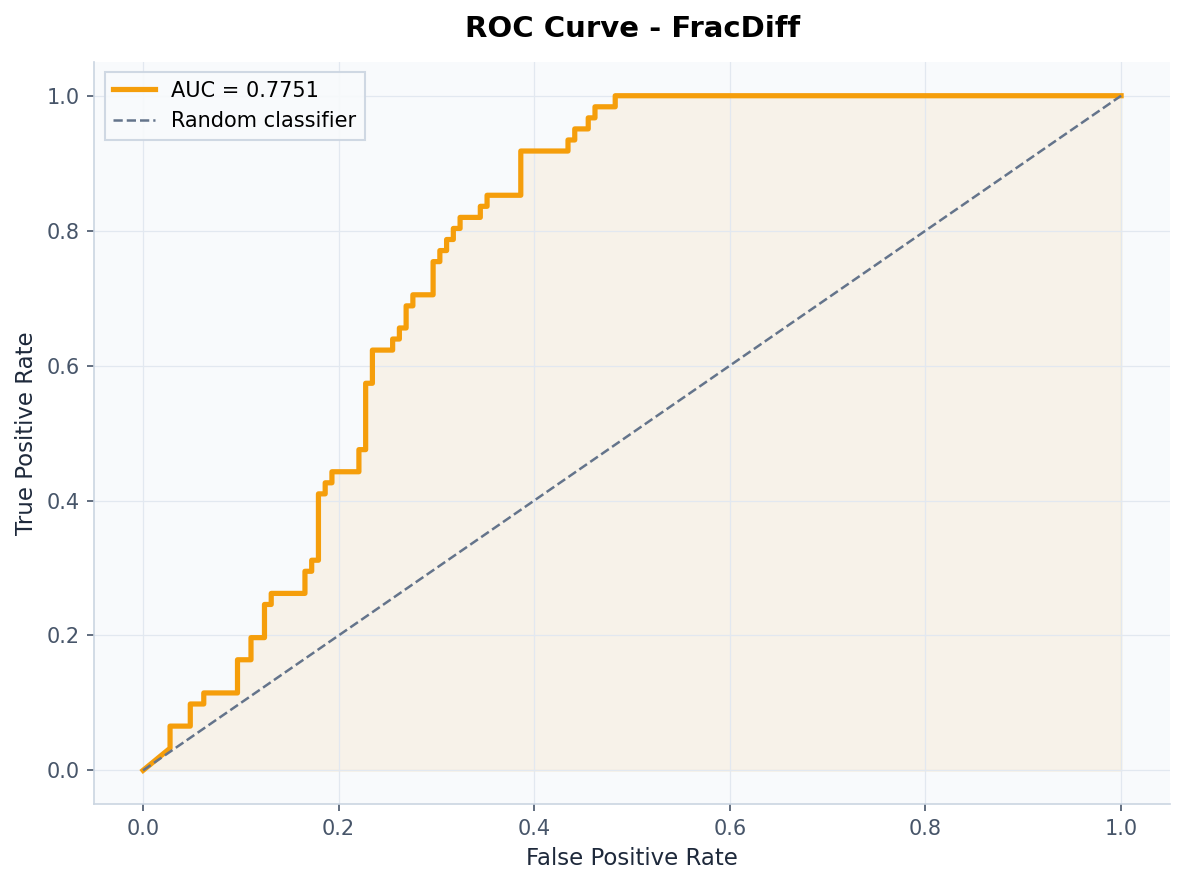

Acc: 0.6748 | Prec: 0.3636 | Rec: 0.1311 | F1: 0.1928 | AUC: 0.7751


In [25]:
print("=" * 60)
print("CNN - FRACTIONALLY DIFFERENCED (GAF)")
print("=" * 60)

X_cnn_fd = X_gaf_fd.reshape(-1, GAF_WINDOW, GAF_WINDOW, 1)
sp_cnn_fd = int(TRAIN_RATIO * len(X_cnn_fd))
X_tr_cfd, X_te_cfd = X_cnn_fd[:sp_cnn_fd], X_cnn_fd[sp_cnn_fd:]
y_tr_cfd, y_te_cfd = y_gaf_fd[:sp_cnn_fd], y_gaf_fd[sp_cnn_fd:]

print(f"Train: {len(X_tr_cfd)} | Test: {len(X_te_cfd)}")
print(f"Class distribution - Train: {np.bincount(y_tr_cfd)} | Test: {np.bincount(y_te_cfd)}")

cnn_fd = build_cnn()
hist_cfd = cnn_fd.fit(X_tr_cfd, y_tr_cfd,
                       epochs=CNN_EPOCHS, batch_size=BATCH_SIZE,
                       validation_split=VAL_SPLIT,
                       callbacks=make_callbacks(CNN_PATIENCE, CNN_PATIENCE//2), verbose=0)
print(f"Best epoch: {np.argmin(hist_cfd.history['val_loss']) + 1}")

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
axes[0].plot(hist_cfd.history['loss'],         color=C['amber'], lw=2,   label='Train Loss')
axes[0].plot(hist_cfd.history['val_loss'],     color=C['rose'],       lw=2, ls='--', label='Val Loss')
axes[0].set_title('CNN Loss - FracDiff')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy'); axes[0].legend()

axes[1].plot(hist_cfd.history['accuracy'],     color=C['amber'], lw=2,   label='Train Acc')
axes[1].plot(hist_cfd.history['val_accuracy'], color=C['violet'],     lw=2, ls='--', label='Val Acc')
axes[1].set_title('CNN Accuracy - FracDiff')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

y_prob_cfd = cnn_fd.predict(X_te_cfd, verbose=0).ravel()
y_pred_cfd = (y_prob_cfd > 0.5).astype(int)

cm = confusion_matrix(y_te_cfd, y_pred_cfd)
fig, ax = plt.subplots(figsize=FIG_SQ)
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            cmap=sns.color_palette(["#FEE2E2","#DCFCE7"], as_cmap=True),
            annot_kws={'size': 16, 'weight': 'bold'},
            xticklabels=['Down','Up'], yticklabels=['Down','Up'],
            linewidths=1.5, linecolor='white', cbar=False)
ax.set_title('Confusion Matrix - FracDiff')
ax.set_xlabel('Predicted', labelpad=8); ax.set_ylabel('Actual', labelpad=8)
for t in ax.texts:
    val = int(t.get_text())
    t.set_color(C['dark'])
plt.tight_layout(); plt.show()

fpr_, tpr_, _ = roc_curve(y_te_cfd, y_prob_cfd)
auc_ = roc_auc_score(y_te_cfd, y_prob_cfd)
fig, ax = plt.subplots(figsize=FIG_SQ)
ax.plot(fpr_, tpr_, color=C['amber'], lw=2.5, label=f'AUC = {auc_:.4f}')
ax.fill_between(fpr_, tpr_, alpha=0.08, color=C['amber'])
ax.plot([0,1],[0,1], color=C['slate'], lw=1.2, ls='--', label='Random classifier')
ax.set_title('ROC Curve - FracDiff')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(); plt.tight_layout(); plt.show()

acc_  = accuracy_score(y_te_cfd, y_pred_cfd)
prec_ = precision_score(y_te_cfd, y_pred_cfd)
rec_  = recall_score(y_te_cfd, y_pred_cfd)
f1_   = f1_score(y_te_cfd, y_pred_cfd)
print(f"Acc: {acc_:.4f} | Prec: {prec_:.4f} | Rec: {rec_:.4f} | F1: {f1_:.4f} | AUC: {auc_:.4f}")
cnn_metrics['FracDiff'] = dict(Accuracy=acc_, Precision=prec_, Recall=rec_, F1=f1_, AUC=auc_)

In [ ]:
print("=" * 60)
print("CNN MODELS COMPARISON")
print("=" * 60)
cnn_df = pd.DataFrame(cnn_metrics).T
print(cnn_df.round(4))

CNN MODELS COMPARISON
             Accuracy  Precision  Recall      F1     AUC
Levels         0.5217     0.4412  0.0820  0.1382  0.5398
Log-Returns    0.4859     0.4954  0.8232  0.6186  0.5145
FracDiff       0.6845     0.4333  0.2131  0.2857  0.7760


# Final Summary - All Models

In [28]:
print("=" * 70)
print("MASTER COMPARISON — ALL MODELS AND ALL METRICS")
print("=" * 70)

print("\n── MLP Regression Metrics ──────────────────────────────────")
print(pd.DataFrame(mlp_metrics).T.round(6).to_string())

print("\n── CNN Classification Metrics ───────────────────────────────")
print(pd.DataFrame(cnn_metrics).T.round(4).to_string())

print("\n── Architecture Comparison ──────────────────────────────────")
arch_data = {
    "Aspect":        ["Task",           "Input",            "Spatial awareness",
                      "Best series",    "Scaler",           "Cost"],
    "MLP":           ["Regression",     "Flat lag vector",  "None",
                      "Log-returns",    "StandardScaler",   "Low"],
    "CNN + GAF":     ["Classification", "24×24 GAF image",  "Local conv filters",
                      "FracDiff",       "None (GAF ∈ [-1,1])","Higher"],
}
print(pd.DataFrame(arch_data).set_index("Aspect").to_string())

print("\n── Best Model per Metric ────────────────────────────────────")
print(f"  MLP  lowest RMSE : {min(mlp_metrics, key=lambda k: mlp_metrics[k]['RMSE'])}")
print(f"  MLP  highest R²  : {max(mlp_metrics, key=lambda k: mlp_metrics[k]['R2'])}")
print(f"  CNN  highest Acc : {max(cnn_metrics, key=lambda k: cnn_metrics[k]['Accuracy'])}")
print(f"  CNN  highest AUC : {max(cnn_metrics, key=lambda k: cnn_metrics[k]['AUC'])}")

MASTER COMPARISON — ALL MODELS AND ALL METRICS

── MLP Regression Metrics ──────────────────────────────────
                      MSE         RMSE         MAE        R2
Levels       9.951610e+05   997.577548  719.368099  0.952494
Log-Returns  9.620000e-04     0.031016    0.020896  0.009814
FracDiff     1.964784e+06  1401.707376  607.777097  0.085608

── CNN Classification Metrics ───────────────────────────────
             Accuracy  Precision  Recall      F1     AUC
Levels         0.5524     0.6818  0.0820  0.1463  0.5011
Log-Returns    0.5090     0.5077  1.0000  0.6735  0.5346
FracDiff       0.6748     0.3636  0.1311  0.1928  0.7751

── Architecture Comparison ──────────────────────────────────
                               MLP            CNN + GAF
Aspect                                                 
Task                    Regression       Classification
Input              Flat lag vector      24×24 GAF image
Spatial awareness             None   Local conv filters
Best series  